# interpolation functions

In [2]:
%cd ../src/qtt_interpolation
import torchtt as tntt
import torch as tn
from utils import *

def d_coeff_mat(M, order=0):
    if order == 0:
        return M
    elif order == 1:
        return M[:, 1:] * tn.tensor([1, 2, 3], dtype=M.dtype)
    elif order == 2:
        return M[:, 2:] * tn.tensor([2, 6], dtype=M.dtype)
    else:
        raise ValueError("Only derivative orders 0, 1, and 2 are supported.")
    

def qtt_skcubic3d_p(mps, fscale, eps = 1e-15, order = 1, p_derivative = [0,0,0]):


    ni = len(mps.N)//3
    nc = fscale - ni 

    id0 = I_qtt(ni)
    ones = tntt.ones([2]*ni)
    onesf = tntt.ones([2]*nc)

    if order == 1:
        # Build Kernel interpolant
        Mkc = tn.tensor([
            [0, 2, 0, 0],
            [-1, 0, 1, 0],
            [2, -5, 4, -1],
            [-1, 3, -3, 1]
        ], dtype=tn.float64) /2
        Mkct = Mkc.t()

    elif order == 2:
        Mkct = tn.tensor([
            [1, -3, 3, -1],
            [4, 0, -6, 3],
            [1, 3, 3, -3],
            [0,0, 0, 1]
        ], dtype=tn.float64) /6

    sm10 = P_qtt( 2**ni -1, ni)
    O20 = P_qtt( 2**ni -2, ni)
    Om10 = P_qtt( 1, ni)

    epsp = 1e-12
    Mx = d_coeff_mat(Mkct, p_derivative[0]) 
    My = d_coeff_mat(Mkct, p_derivative[1])
    Mz = d_coeff_mat(Mkct, p_derivative[2])
    polsx = [tntt.kron( ones, zukron3(tntt.TT(qtt_polynomial_cores(Mx[i], nc)) , onesf,onesf) ).round(epsp) for i in range(4)]
    polsy = [tntt.kron( ones, zukron3( onesf , tntt.TT( qtt_polynomial_cores(My[i], nc)), onesf )).round(epsp) for i in range(4)]
    polsz = [tntt.kron( ones, zukron3( onesf , onesf , tntt.TT( qtt_polynomial_cores(Mz[i], nc)) )).round(epsp) for i in range(4)]
    
    zones3 = zukron3(onesf, onesf, onesf)

    oneso = tntt.eye([2]*nc)
    id = tntt.kron(id0,oneso)
    sm1 = tntt.kron(sm10,oneso)
    Om1 = tntt.kron(Om10,oneso)
    O2 = tntt.kron(O20,oneso)

    mps = tntt.kron(mps, zones3 )
    #interpolate y,
    f_ky = (zukron3(id,Om1,id) @ mps) * ( polsy[0] ) + ( mps * polsy[1] ) + ( zukron3(id,sm1,id) @ mps ) * (polsy[2]) + ( zukron3(id,O2,id) @ mps ) * (polsy[3]) 
    f_ky = f_ky.round(eps)

    #interpolate x
    f_kxy =  (zukron3(Om1,id,id) @ f_ky) *( polsx[0] ) + ( f_ky *  polsx[1] ) + ( zukron3(sm1,id,id) @ f_ky ) * (polsx[2]) +  ( zukron3(O2,id,id) @ f_ky ) * ( polsx[3])
    f_kxy = f_kxy.round(eps)

    #interpolate z
    f_kcs = (zukron3(id,id,Om1) @ f_kxy) * ( polsz[0] ) + ( f_kxy * polsz[1] ) + ( zukron3(id,id,sm1) @ f_kxy ) * (polsz[2]) + ( zukron3(id,id,O2) @ f_kxy ) * (polsz[3]) 
    f_kcs = f_kcs.round(eps)

    return f_kcs




def lcf(cores):
    R = [1] + [c.shape[2] for c in cores[:-1]] + [1]
    return tntt._decomposition.lr_orthogonal( cores, R, False )[0]

def rcf(cores):
    R = [1] + [c.shape[2] for c in cores[:-1]] + [1]
    return tntt._decomposition.rl_orthogonal( cores, R, False )[0]

c:\Users\siddhartha.morales\OneDrive - Technology Innovation Institute\Documents\GitHub\QTT-polynomial-interpolation\src\qtt_interpolation


c:\Users\siddhartha.morales\OneDrive - Technology Innovation Institute\Documents\GitHub\QTT-polynomial-interpolation\ttinter\Lib\site-packages\torchtt\_dmrg.py:19: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn("\x1B\nC++ implementation not available. Using pure Python.\n\033")
c:\Users\siddhartha.morales\OneDrive - Technology Innovation Institute\Documents\GitHub\QTT-polynomial-interpolation\ttinter\Lib\site-packages\torchtt\_amen.py:21: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn(
c:\Users\siddhartha.morales\OneDrive - Technology Innovation Institute\Documents\GitHub\QTT-polynomial-interpolation\ttinter\Lib\site-packages\torchtt\solvers.py:21: UserWarning: 
C++ implementation not available. Using pure Python.

  warnings.warn(
c:\Users\siddhartha.morales\OneDrive - Technology Innovation Institute\Documents\GitHub\QTT-polynomial-interpolation\ttinter\Lib\site-packages\torchtt\cpp.py:12: UserWarning: 
C++ impl

In [3]:
from torchtt._decomposition import SVD, rank_chop, lr_orthogonal
import sys
# Tree TN functions and compressions
def get_roott(comb):
    """
    Build TT cores from comb cores.
    Each comb[i][0] is assumed to be (1, Rprod, N_i) with Rprod = rL_i * rR_i.
    We recover (rL_i, N_i, rR_i) using the previous core's right rank.
    """
    cores = []
    n_trunks = len(comb)

    for i in range(n_trunks):
        c = comb[i][0]
        assert c.dim() == 3, f"comb[{i}][0] must be 3D, got {tuple(c.shape)}"
        one, Rprod, N = c.shape
        assert one == 1, f"expected left singleton (1, Rprod, N) at site {i}, got {tuple(c.shape)}"

        # left rank (L) is previous core's right rank; 1 at the first site
        L = 1 if i == 0 else cores[-1].shape[2]
        assert (Rprod % L) == 0, f"Rprod={Rprod} not divisible by L={L} at site {i}"
        R = Rprod // L

        # Reorder and split: (1, Rprod, N) -> (1, N, Rprod) -> (1, N, L, R) -> (L, N, R)
        tmp = c.permute(0, 2, 1).contiguous()     # (1, N, Rprod)
        tmp = tmp.reshape(1, N, L, R)             # (1, N, L, R)
        core_i = tmp.permute(2, 1, 3, 0).contiguous().reshape(L, N, R)  # (L, N, R)

        cores.append(core_i)

    return cores

def update_comb(comb, root):
    """
    root[i]: TT core with shape (L, N, R)
    comb[i][0] will be set to shape (1, L*R, N) with R fastest inside L*R.
    """
    for i in range(len(comb)):
        L, N, R = root[i].shape
        tmp = root[i].permute(0, 2, 1).contiguous()  # (L, R, N)
        comb[i][0] = tmp.reshape(1, L * R, N)
    return

def get_R(root):
    r = [1]
    for i in range(len(root)):
        r.append(root[i].shape[2])
    return r


def comb_full(comb):

    root = get_roott(comb)
    r = get_R(root)
    f_tensors = []
    for i in range(len(comb)):
        if i == 0 or i == len(comb)-1:
            f_tensors.append(tntt.TT(comb[i],eps=1e-15).full())
        else:
            f_tensors.append(tntt.TT(comb[i],eps=1e-15).full().reshape(r[i],r[i+1],-1).swapaxes(1,2))

    full = tn.einsum('xa, xby, yc -> abc',*f_tensors)
        
    return full

def comb_full2(comb):
    root = tntt.TT(get_roott(comb),eps=1e-15)
    R = root.full()        # core, indices: a,b,c
    r = root.N             # mode sizes (for the factor reshapes)
    # factors to matrices: (r[i], -1) -> ax, by, cz
    A = comb[0][1].reshape(r[0], -1).contiguous()
    B = comb[1][1].reshape(r[1], -1).contiguous()
    C = comb[2][1].reshape(r[2], -1).contiguous()

    # 3D contraction: result has shape (X, Y, Z)
    full3 = tn.einsum('abc, ax, by, cz -> xyz', R, A, B, C)

    full2 = full3.contiguous()
    return full2



def _clone_comb(comb):
    new = []
    for branch in comb:
        new_branch = []
        for t in branch:
            new_branch.append(t.clone())
        new.append(new_branch)
    return new

def tree_compress(comb, eps=1e-8):
    """
    Returns a compressed COPY of `comb` (does not modify the input).
    Assumes external helpers exist: rcf, lcf, update_comb, get_roott, tntt.TT
    """
    out = _clone_comb(comb)

    # right-orthogonalize branches
    for i in range(len(out)):
        out[i] = rcf(out[i])

    # get the root (TT), compress it, then left-orthogonalize
    root = get_roott(out)
    roott_tt = tntt.TT(root,eps=eps).round(eps).cores
    roott_tt = lcf(roott_tt)
    #print( (root- tntt.TT(roott_tt,eps=1e-15)).norm().item()/root.norm().item()  )

    # push updated core info back into branches
    update_comb(out, roott_tt)

    # compress branches (except the first)
    for i in range(len(out) - 1, 0, -1):
        out[i] = rcf(tntt.TT(out[i],eps=eps).round(eps).cores)

    # recompute a right-orthogonal root cores list
    roott_cores = rcf(get_roott(out))    # list of cores; roott_cores[0] has shape (L, N, R)
    # push updated core info back into branches
    update_comb(out, roott_cores)
    
    # update the first branch head from root[0] with CORRECT reshape
    L, N, R = roott_cores[0].shape
    tmp = roott_cores[0].permute(0, 2, 1).contiguous()  # (L, R, N) so (L,R) are adjacent
    out[0][0] = tmp.reshape(1, L * R, N)                # (1, L*R, N)

    # compress the first branch
    out[0] = tntt.TT(out[0],eps=eps).round(eps).cores

    return out

def round_tt(tt_cores,R,eps,Rmax,is_ttm=False):
    """
    Rounds a TT-tensor (tt_cores have to be orthogonal)

    Parameters
    ----------
    tt_cores : list of torch tensors.
        Orthogonal TT cores.
    R : list of integers of length d+1.
        ranks of the TT-decomposition.
    eps : double.
        desired rounding accuracy.
    Rmax : list of integers
        the maximum rank that is allowed.

    Returns
    -------
    tt_cores : list of torch tensors.
        The TT-cores of the rounded tensor.
    R : list of inteders of length d+1.
        rounded ranks.

    """
    d = len(tt_cores)
    if d == 1:
        tt_cores = [tt_cores[0].clone()]
        return tt_cores, R
    tt_cores, R = lr_orthogonal(tt_cores, R, is_ttm)
    core_now = tt_cores[-1]
    eps = eps / np.sqrt(d-1) 

    
    for i in range(d-1,0,-1):
        core_next = tt_cores[i-1]
        
        core_now = tn.reshape(core_now,[R[i],-1])
        core_next = tn.reshape(core_next,[-1,R[i]])
        
        
        U, S, V = SVD(core_now)
        if S.is_cuda:
            r_now = min([Rmax[i],rank_chop(S.cpu().numpy(),tn.linalg.norm(S).cpu().numpy()*eps)])
        else:
            r_now = min([Rmax[i],rank_chop(S.numpy(),tn.linalg.norm(S).numpy()*eps)])
    
        U = U[:,:r_now]
        S = S[:r_now]
        V = V[:r_now,:]
        
        U = U @ tn.diag(S)
        R[i] = r_now
        core_next = core_next @ U
        core_now = V
        
        tt_cores[i] = tn.reshape(core_now,[R[i]]+list(tt_cores[i].shape[1:-1])+[R[i+1]])
        tt_cores[i-1] = tn.reshape(core_next,[R[i-1]]+list(tt_cores[i-1].shape[1:-1])+[R[i]])
        
        core_now = core_next
    
    return tt_cores, R

def tree_compress_2(comb0, eps=1e-8, Rmax = sys.maxsize, Rbmax = sys.maxsize,is_ttm=False):
    comb = _clone_comb(comb0)
    d = len(comb)
    fd = len(comb[0])
    if not isinstance(Rmax, list):
            Rmax = [1] + d*[Rmax] + [1]
    if not isinstance(Rbmax, list):
            Rbmax = [1] + fd*[Rbmax] + [1]
    for i in range(d-1,0,-1):
        Rb = get_R(comb[i] )
        comb[i],_ = round_tt(comb[i],Rb,eps,Rbmax)

        root = get_roott(comb)
        R = get_R(root)
        root, R = lr_orthogonal(root,R,is_ttm)  
        core_now = root[i]
        core_next = root[i-1]
        eps = eps / np.sqrt(d-1) 
        core_now = tn.reshape(core_now,[R[i],-1])
        core_next = tn.reshape(core_next,[-1,R[i]])
        U, S, V = SVD(core_now)
        if S.is_cuda:
            r_now = min([Rmax[i],rank_chop(S.cpu().numpy(),tn.linalg.norm(S).cpu().numpy()*eps)])
        else:
            r_now = min([Rmax[i],rank_chop(S.numpy(),tn.linalg.norm(S).numpy()*eps)])
        U = U[:,:r_now]
        S = S[:r_now]
        V = V[:r_now,:]
        
        U = U @ tn.diag(S)
        R[i] = r_now
        core_next = core_next @ U
        core_now = V
        
        root[i] = tn.reshape(core_now,[R[i]]+list(root[i].shape[1:-1])+[R[i+1]])
        root[i-1] = tn.reshape(core_next,[R[i-1]]+list(root[i-1].shape[1:-1])+[R[i]])
        
        update_comb(comb, root)
        
    comb[0],_ = round_tt(comb[0],get_R(comb[0]),eps,Rbmax)

    return comb

# --------- build comb from (root core, factor matrices U) ----------
def combqtt(core, U, eps=1e-10):
    """
    Build 'comb' branches:
      - QTT-decompose each U[i] with dims [ranks[i], 2, 2, ..., 2]
      - Replace its first QTT core by a 'head' that couples the root TT ranks.
    Returns: list of branches, each a list of TT cores.
    """
    ranks = list(core.shape)
    roott = tntt.TT(core, ranks, eps=eps)           # root TT with 3 cores (rL, N, rR)
    rc = roott.cores                                 # each core: (rL, N, rR)
    rr = roott.R                                     # TT ranks [r0, r1, r2, r3], r3=1

    comb = []
    for i in range(3):
        Ui = U[i].T
        assert Ui.shape[0] == ranks[i], f"U[{i}] must be (ranks[{i}], 2**p)"
        cols = Ui.shape[1]
        p = int(np.log2(cols));  assert 2**p == cols, f"U[{i}].shape[1] must be power of 2"

        # QTT of Ui: dims [ranks[i], 2, 2, ..., 2]
        btt = tntt.TT(Ui, [ranks[i]] + [2]*p, eps=eps).cores
        # head from root core: flatten (rL, N, rR) -> (rL*rR, N) with rR-fast
        c = rc[i]  # (rL, N, rR)
        ri = c.permute(0, 2, 1).contiguous().reshape(rr[i]*rr[i+1], ranks[i])  # (a, b)

        # contract with first QTT core (1, ranks[i], r1): ab, xbc -> xac  => (1, a, r1)
        head = tn.einsum('ab,xbc->xac', ri, btt[0])
        comb.append([head] + btt[1:])

    return comb


# --------- reconstruct full dense tensor from comb ----------
def combqtt_full(comb):
    """
    Reconstruct the full dense tensor of shape (2**p0, 2**p1, 2**p2).
    Strategy:
      - Recover the root coupling tensor R from comb (via get_roott).
      - For each branch i, contract all its cores to a dense (rL*rR, 2**p_i),
        then reshape to (rL, rR, 2**p_i).
      - Contract: full[x,y,z] = sum_{a,b,c} R[a,b,c] * F0[a,b,x] * F1[b,c,y] * F2[c,*,z]
    """
    root = get_roott(comb)          # TT with 3 cores; root.full() -> (a,b,c)

    rr = get_R(root)                     # TT ranks [r0, r1, r2, r3], expect r3 == 1

    # Dense factors from branches
    F0 = tntt.TT(comb[0], eps=1e-15).full()  # (r0*r1, 2**p0)
    F1 = tntt.TT(comb[1], eps=1e-15).full()  # (r1*r2, 2**p1)
    F2 = tntt.TT(comb[2], eps=1e-15).full()  # (r2*r3, 2**p2)

    F0 = F0.reshape(rr[1], -1)        # (a, b, X)
    F1 = F1.reshape(rr[1], rr[2], -1)        # (b, c, Y)
    F2 = F2.reshape(rr[2], -1)        # (c, r3, Z)

    # Contract to full (X, Y, Z)
    full = tn.einsum('bx,bcy,cz->xyz', F0, F1, F2)
    return full

    

def tu_to_comb(core, U, eps=1e-10):
    comb = []
    ranks = list(core.shape)
    roott = tntt.TT(core, ranks, eps=eps)
    roott_cores = roott.cores      # each core: (rL, N, rR)
    rranks = roott.R               # TT ranks

    for i in range(len(ranks)):
        # factor "btt": swap to (pd, bd, 1)
        s = U[i].shape
        btt = U[i].transpose(0, 1).reshape(s[1], s[0], 1).contiguous()

        # core "ri": make (1, rL*rR, N) with rR fastest inside the product
        c = roott_cores[i]                         # (rL, N, rR)
        ri = c.permute(0, 2, 1).contiguous()       # (rL, rR, N)
        ri = ri.reshape(1, rranks[i]*rranks[i+1], ranks[i])  # (1, rL*rR, N)

        comb.append([ri.to(tn.float64), btt.to(tn.float64)])

    return comb

import torch.nn.functional as F

def blockdiag_first_site(c1, c2):
    """
    c1: (1, pd, bd1)
    c2: (1, pd, bd2)
    returns: (1, pd, bd1+bd2)
    """
    bd1, bd2 = c1.shape[2], c2.shape[2]
    return F.pad(c1, (0, bd2, 0, 0, 0, 0)) + F.pad(c2, (bd1, 0, 0, 0, 0, 0))

def blockdiag_last_site(c1, c2):
    """
    c1: (bd1, pd, 1)
    c2: (bd2, pd, 1)
    returns: (bd1+bd2, pd, 1)
    """
    bd1, bd2 = c1.shape[0], c2.shape[0]
    return F.pad(c1, (0, 0, 0, 0, 0, bd2)) + F.pad(c2, (0, 0, 0, 0, bd1, 0))

def blockdiag_core(c1, c2,pad_left: bool = True, pad_right: bool = True) :
    """
    Put c1 in the top-left block and c2 in the bottom-right block of the rank dims.
    c1, c2 shapes: (rL, N, rR); must have the same N.
    pad_left/right allow skipping padding on the boundary ends if needed.
    """
    assert c1.dim() == 3 and c2.dim() == 3, "expected 3D cores (rL, N, rR)"
    assert c1.shape[1] == c2.shape[1], "mode size mismatch"

    r1L, N, r1R = c1.shape
    r2L, _, r2R = c2.shape

    # pad tuples are (lastL, lastR, midL, midR, firstL, firstR)
    pad_c1 = (
        0, (r2R if pad_right else 0),  # add zeros to the RIGHT of last dim
        0, 0,                          # no padding on the mode dim
        0, (r2L if pad_left else 0),   # add zeros to the RIGHT of first dim
    )
    pad_c2 = (
        (r1R if pad_right else 0), 0,  # add zeros to the LEFT  of last dim
        0, 0,
        (r1L if pad_left else 0), 0,   # add zeros to the LEFT  of first dim
    )

    return F.pad(c1, pad_c1) + F.pad(c2, pad_c2)

def blockdiag_3bond(c1: tn.Tensor, c2: tn.Tensor,
                    grow=(True, True, True)) -> tn.Tensor:
    """
    Block-diagonal merge of two 3-bond cores.
    c1, c2: (rL, rM, rR)  (all dimensions are bond ranks)
    grow: which legs to grow (L, M, R). If a leg is False, that dim must match.

    Returns: (rL1 + rL2 if grow[0] else rL1,  rM1 + rM2 if grow[1] else rM1,
              rR1 + rR2 if grow[2] else rR1)
    """
    assert c1.dim() == 3 and c2.dim() == 3, "expected 3D tensors (rL, rM, rR)"
    r1L, r1M, r1R = c1.shape
    r2L, r2M, r2R = c2.shape

    # If a leg is not grown, sizes must match
    if not grow[0]: assert r1L == r2L, "left ranks must match when not growing"
    if not grow[1]: assert r1M == r2M, "middle ranks must match when not growing"
    if not grow[2]: assert r1R == r2R, "right ranks must match when not growing"

    # torch.nn.functional.pad order for 3D: (lastL, lastR, midL, midR, firstL, firstR)
    pad_c1 = (
        0, (r2R if grow[2] else 0),   # dim2 (rR): add zeros on the RIGHT
        0, (r2M if grow[1] else 0),   # dim1 (rM): add zeros on the RIGHT
        0, (r2L if grow[0] else 0),   # dim0 (rL): add zeros on the RIGHT
    )
    pad_c2 = (
        (r1R if grow[2] else 0), 0,   # dim2: add zeros on the LEFT
        (r1M if grow[1] else 0), 0,   # dim1: add zeros on the LEFT
        (r1L if grow[0] else 0), 0,   # dim0: add zeros on the LEFT
    )
    return F.pad(c1, pad_c1) + F.pad(c2, pad_c2)

def _head_to_3bond(head, L, R):
    # head: (1, L*R, rM) with R fastest inside L*R  →  (L, rM, R)
    x = head.contiguous().reshape(1, L*R, -1)     # ensure viewable
    x = x.reshape(L, R, -1).permute(0, 2, 1).contiguous()  # (L, rM, R)
    return x

def _3bond_to_head(x):
    # x: (Lsum, rM, Rsum)  →  (1, Lsum*Rsum, rM) with Rsum fastest
    Ls, rM, Rs = x.shape
    return x.permute(0, 2, 1).contiguous().reshape(1, Ls*Rs, rM)

def comb_sum(c1, c2):
    assert len(c1) == len(c2)
    out = []

    root1 = get_roott(c1)
    root2 = get_roott(c2)
    r1 = get_R(root1)   # TT ranks of root1: [r0, r1, r2, r3]
    r2 = get_R(root2)   # TT ranks of root2

    n_trunks = len(c1)
    for i in range(n_trunks):
        branch = []
        m = len(c1[i])
        for j in range(m):
            A, B = c1[i][j], c2[i][j]

            if j == 0:
                if i == 0 or i == n_trunks - 1:
                    # boundary branch head already has shape (1, a, rM) ~ (rL=1, rM=a, rR=rM)
                    # grow middle & right, keep left (1) unchanged
                    branch.append(blockdiag_3bond(A, B, grow=(False, True, True)))
                else:
                    # interior branch: turn head (1, L*R, rM) into (L, rM, R),
                    # block-diag, then map back to (1, (L+L’)*(R+R’), rM)
                    L1, R1 = r1[i],   r1[i+1]
                    L2, R2 = r2[i],   r2[i+1]

                    A3 = _head_to_3bond(A, L1, R1)
                    B3 = _head_to_3bond(B, L2, R2)

                    X = blockdiag_3bond(A3, B3)   # (L1+L2, rM, R1+R2)
                    H = _3bond_to_head(X)         # (1, (L1+L2)*(R1+R2), rM)
                    branch.append(H)

            elif j == m - 1:
                # last site of a QTT branch: (bd, 2, 1)
                branch.append(blockdiag_last_site(A, B))

            else:
                # middle QTT cores: (rL, 2, rR)
                branch.append(blockdiag_core(A, B))

        out.append(branch)
    return out

def comb_op(comb,op,leg_indx):

    d = comb[leg_indx][0].shape[1]
    c_op = tntt.kron( tntt.TT(tn.eye(d,dtype=tn.float64)), op )
    nc = c_op @ tntt.TT(comb[leg_indx])
    comb[leg_indx] = nc.cores
    return 


def comb_comp(comb):
    entries = 0
    dim = 1
    for i in range(len(comb)):
        entries += sum([tn.numel(c) for c in comb[i]])
        N = [comb[i][j].shape[1] for j in range(1,len(comb[i]))]
        dim *= int(np.prod(np.array(N)))
    return entries/dim

def tt_comp(tt):
    d = 1
    for i in range(len(tt.N)):
        d *= int(tt.N[i])
    return sum([tn.numel(c) for c in tt.cores])/d


def comb_max_rank(comb):
    rmax = 0
    root = get_roott(comb)
    R = get_R(root)
    rmax = max(rmax, max(R))
    for i in range(len(comb)):
        rmax = max(rmax, max(tntt.TT(comb[i]).R))
    
    return rmax

def comb_interpolate_p(comb0,fscale, eps =  1e-14,order = 1, p_derivative = [0,0,0]):

    comb = _clone_comb(comb0)

    ni = len(comb[0])-1
    nc = fscale - ni



    if order == 1:
        # Build Kernel interpolant
        Mkc = tn.tensor([
            [0, 2, 0, 0],
            [-1, 0, 1, 0],
            [2, -5, 4, -1],
            [-1, 3, -3, 1]
        ], dtype=tn.float64) /2
        Mkct = Mkc.t()

    elif order == 2:
        Mkct = tn.tensor([
            [1, -3, 3, -1],
            [4, 0, -6, 3],
            [1, 3, 3, -3],
            [0,0, 0, 1]
        ], dtype=tn.float64) /6

    sm10 = P_qtt( 2**ni -1, ni)
    O20 = P_qtt( 2**ni -2, ni)
    Om10 = P_qtt( 1, ni)

    epsp = 1e-14
    Mx = d_coeff_mat(Mkct, p_derivative[0]) 
    My = d_coeff_mat(Mkct, p_derivative[1])
    Mz = d_coeff_mat(Mkct, p_derivative[2])
    polsx = [tntt.TT(qtt_polynomial_cores(Mx[i], nc)).round(epsp) for i in range(4)]
    polsy = [tntt.TT(qtt_polynomial_cores(My[i], nc)).round(epsp) for i in range(4)]
    polsz = [tntt.TT(qtt_polynomial_cores(Mz[i], nc)).round(epsp) for i in range(4)]
    pols = [polsx, polsy, polsz]
    # interpolate dimensions

    for i in range(3):

        d = comb[i][0].shape[1]
        sm1 = tntt.kron( tntt.TT(tn.eye(d,dtype=tn.float64), shape=[(d,d)]), sm10 )
        Om1 = tntt.kron( tntt.TT(tn.eye(d,dtype=tn.float64),shape=[(d,d)]), Om10 )
        O2 = tntt.kron( tntt.TT(tn.eye(d,dtype=tn.float64),shape=[(d,d)]), O20 )

        l = tntt.TT(comb[i],eps=1e-15)

        int_l = tntt.kron(Om1 @  l, pols[i][0]) + tntt.kron(l, pols[i][1]) + tntt.kron(sm1 @ l, pols[i][2]) + tntt.kron(O2 @ l, pols[i][3])

        comb[i] = int_l.round(eps).cores

    comb = tree_compress(comb, eps=eps)

    return comb


# 3D wing

This notebook contains the embedding of a 3D version of basic airplane wing without a winglet. 

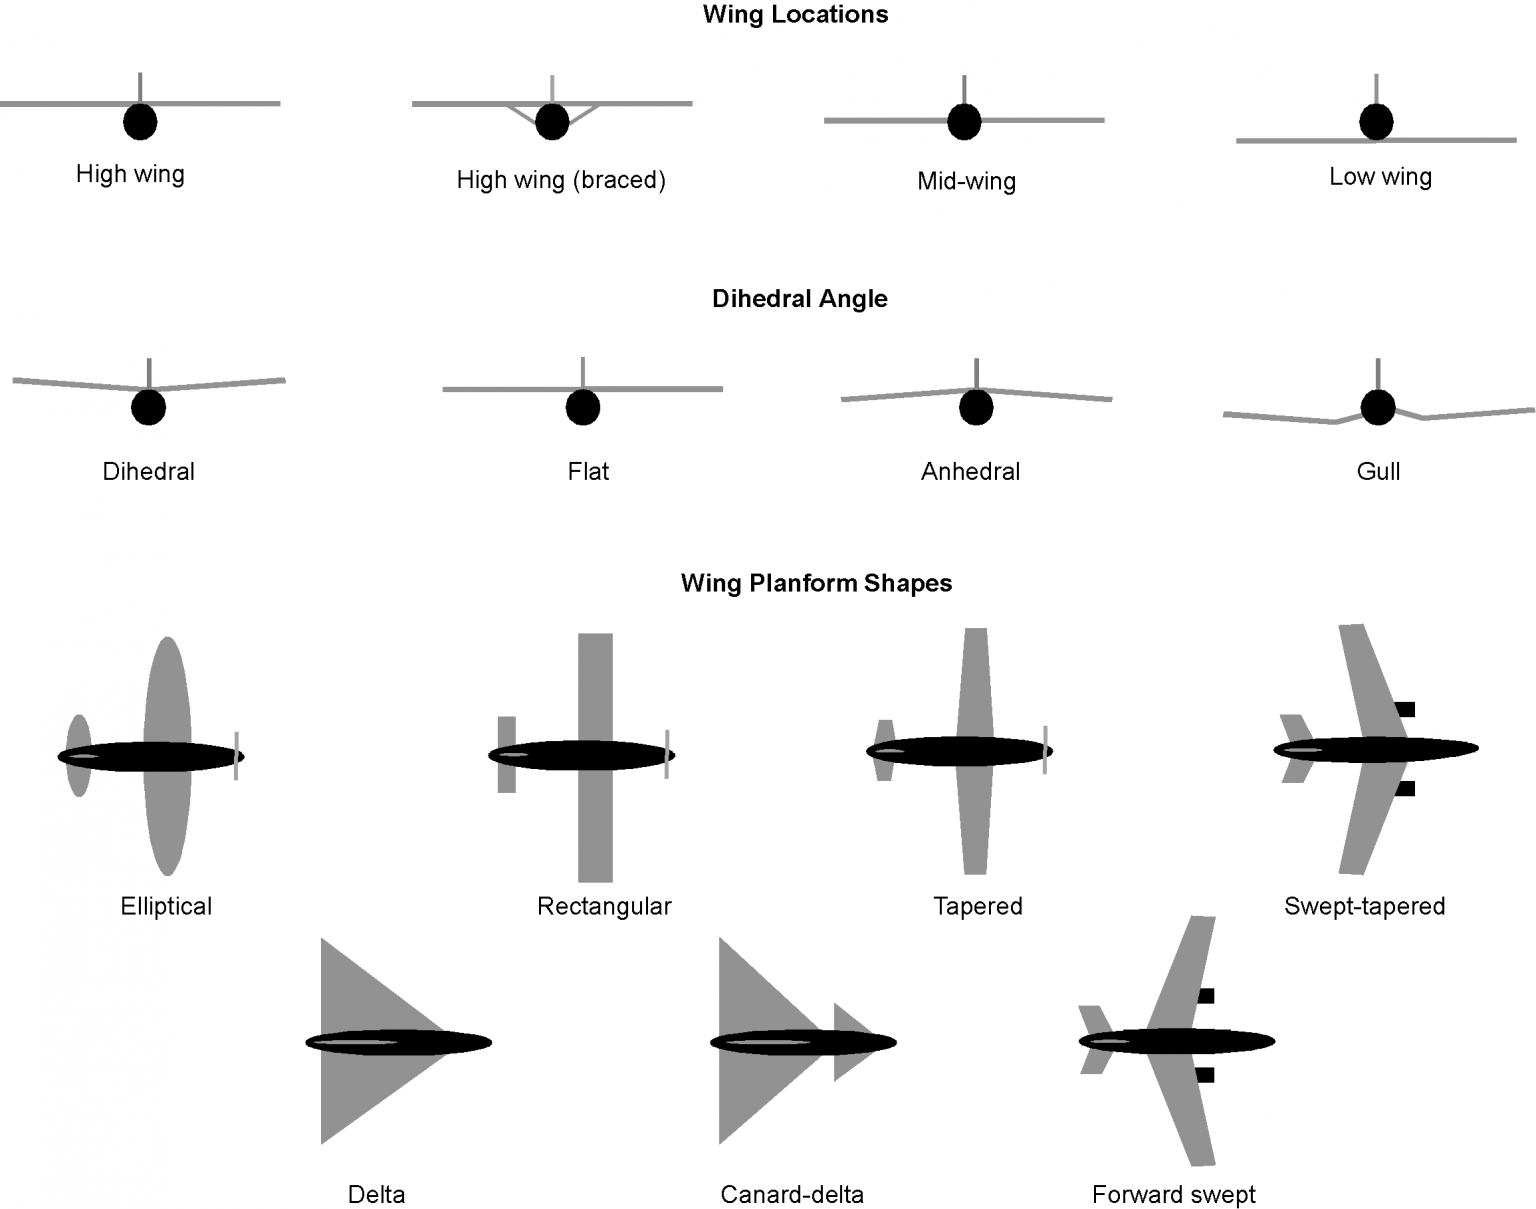

In [3]:
%matplotlib ipympl

## Model 1

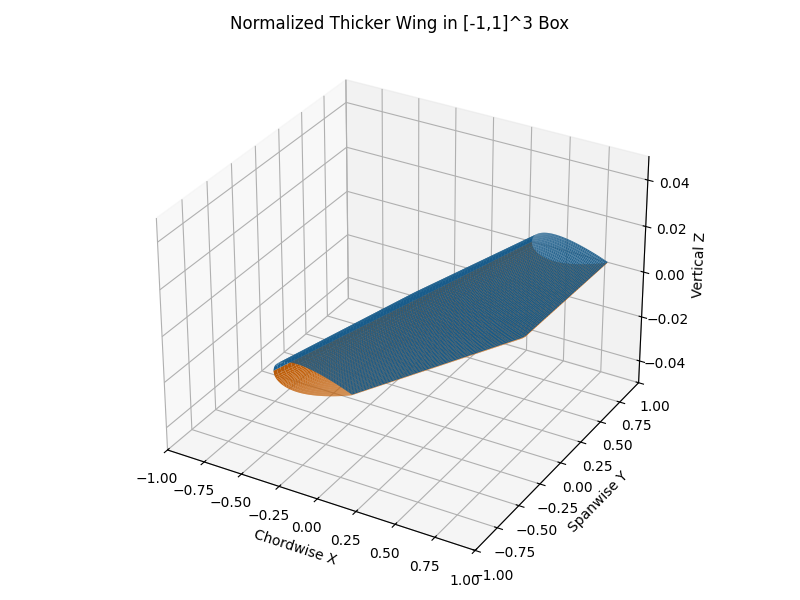

In [372]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Wing parameters
b = 2.0
c_r = 1.0
c_t = 0.5
Lambda_LE = np.deg2rad(15)
phi = 0*np.deg2rad(3)
t = 0.12

def chord(eta): return c_r*(1 - np.abs(eta))/2 + c_t*(1 + np.abs(eta))/2
def x_le(eta): return 0.5 * b * eta * np.tan(Lambda_LE)
def z_planform(eta): return 0.5 * b * eta * np.tan(phi)
def y_t(xi):
    return t * (0.2969 * np.sqrt(xi) - 0.1260 * xi - 0.3516 * xi**2 + 0.2843 * xi**3 - 0.1015 * xi**4)

eta_vals = np.linspace(-1, 1, 80)
xi_vals = np.linspace(0, 1, 80)
XI, ETA = np.meshgrid(xi_vals, eta_vals)

C = chord(ETA)
X_sec = XI * C
Z_thick = C * y_t(XI)

X = x_le(ETA) + X_sec
Y = 0.5 * b * ETA
Z_upper = z_planform(ETA) + Z_thick
Z_lower = z_planform(ETA) - Z_thick

max_val = max(np.abs(X).max(), np.abs(Y).max(), np.abs(Z_upper).max(), np.abs(Z_lower).max())
X /= max_val
Y /= max_val
Z_upper /= max_val
Z_lower /= max_val

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z_upper, rstride=1, cstride=1, shade=True)
ax.plot_surface(X, Y, Z_lower, rstride=1, cstride=1, shade=True)

ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-.05, .05])

ax.set_xlabel('Chordwise X')
ax.set_ylabel('Spanwise Y')
ax.set_zlabel('Vertical Z')
ax.set_title('Normalized Thicker Wing in [-1,1]^3 Box')
plt.tight_layout()
plt.show()


0.012003444536256099 0.75
Approximate max thickness at root chord: 0.01800516680438415


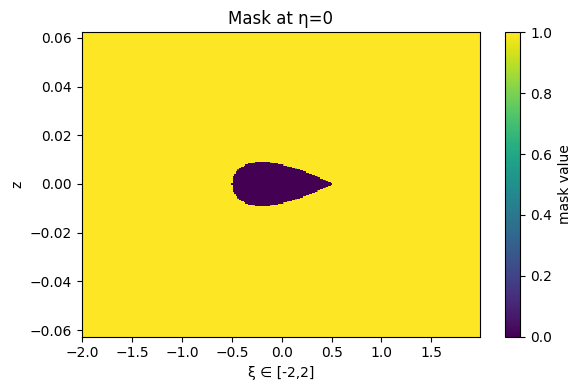

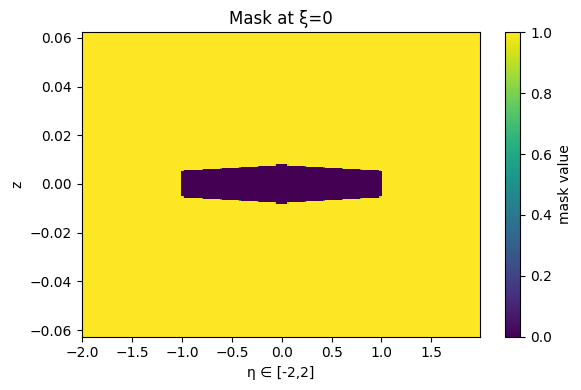

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# --- Wing parameterization ---
b, c_r, c_t = 2.0, 1.0, 0.5
Lambda_LE = np.deg2rad(15)
phi       = 0.0
t         = 0.12

def chord(eta):
    return c_r*(1 - np.abs(eta))/2 + c_t*(1 + np.abs(eta))/2

def z_planform(eta):
    return 0.5 * b * eta * np.tan(phi)

def y_t(xi):
    return t*(0.2969 * np.sqrt(xi)
             - 0.1260 * xi
             - 0.3516 * xi**2
             + 0.2843 * xi**3
             - 0.1015 * xi**4)

# --- Create 3D grid over eta, xi, z  ---
p        = 8
zlim     = 1/16
eta_vals = np.linspace(-2,  2, 2**p, endpoint=False)  # ← extended from [-1,1]
xi_ext   = np.linspace(-2,  2, 2**p, endpoint=False)
z_vals   = np.linspace(-zlim, zlim, 2**p, endpoint=False)
ETA, XI, ZG = np.meshgrid(eta_vals, xi_ext, z_vals, indexing='ij')

# --- Valid chordwise band for surface definition (xi in [-0.5,0.5]) ---
mask_band = (XI[:,:,0] >= -0.5) & (XI[:,:,0] <= 0.5)

# Compute 2D upper/lower z in that band
Zup2d  = np.zeros_like(ETA[:,:,0])
Zlow2d = np.zeros_like(ETA[:,:,0])

xi_param = XI[:,:,0][mask_band] + 0.5
eta_m    = ETA[:,:,0][mask_band]
C_m      = chord(eta_m)
Zt       = C_m * y_t(xi_param)

Zup2d[mask_band]  = z_planform(eta_m) + Zt
Zlow2d[mask_band] = z_planform(eta_m) - Zt

# Broadcast to 3D
Zup3d  = Zup2d[:,:,None] * np.ones_like(ZG)
Zlow3d = Zlow2d[:,:,None] * np.ones_like(ZG)

# Precompute thickness scale
xi_test      = np.linspace(0,1,1000)
max_y_t      = np.max(y_t(xi_test))
c_root       = chord(0.0)
real_thick   = 2 * c_root * max_y_t
print(max_y_t,c_root)
print("Approximate max thickness at root chord:", real_thick)

# --- Build mask, default = 1 everywhere ---
mask = np.ones_like(ZG)

# Define the “core” region in eta and xi:
mask_eta = (ETA[:,:,0] >= -1.0) & (ETA[:,:,0] <= 1.0)
mask_xi  = (XI[:,:,0]  >= -1.0) & (XI[:,:,0]  <= 1.0)
mask_core = mask_eta & mask_xi

# 1) Inside wing (flat) → mask = 0
inside = mask_core[:,:,None] & mask_band[:,:,None] & (ZG >= Zlow3d) & (ZG <= Zup3d)
mask[inside] = 0.0

# 2) Above upper surface → exponential falloff
above = mask_core[:,:,None] & mask_band[:,:,None] & (ZG > Zup3d)
zd_above = ZG - Zup3d
mask[above] = 1 - np.exp(-(1000/real_thick) * zd_above[above])

# 3) Below lower surface → exponential falloff
below = mask_core[:,:,None] & mask_band[:,:,None] & (ZG < Zlow3d)
zd_below = Zlow3d - ZG
mask[below] = 1 - np.exp(-(1000/real_thick) * zd_below[below])

# --- Optional: visualize central slices ---
# η = 0 slice
i0 = np.argmin(np.abs(eta_vals - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(xi_ext, z_vals, mask[i0,:,:].T, shading='auto', cmap='viridis')
plt.xlabel('ξ ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at η=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()

# ξ = 0 slice
j0 = np.argmin(np.abs(xi_ext - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(eta_vals, z_vals, mask[:,j0,:].T, shading='auto', cmap='viridis')
plt.xlabel('η ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at ξ=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()


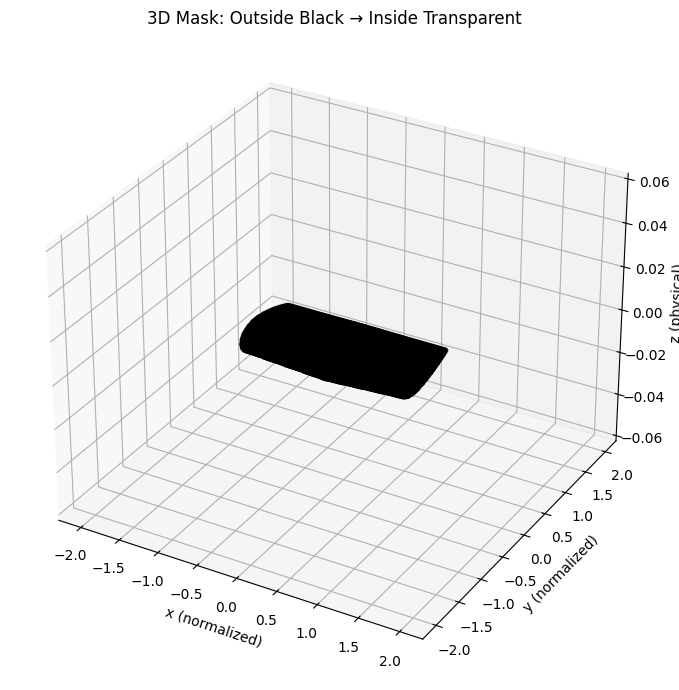

In [47]:
rgba = np.zeros((mask.size, 4))
rgba[:, 3] = (1 - mask).ravel()  # now inside (mask=0) → alpha=1, outside (mask→1) → alpha→0

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    ETA.ravel(), XI.ravel(), ZG.ravel(), c=rgba,marker='o', s=10
)
ax.set_xlabel('x (normalized)')
ax.set_ylabel('y (normalized)')
ax.set_zlabel('z (physical)')
ax.set_title('3D Mask: Outside Black → Inside Transparent')
ax.set_zlim(-zlim, zlim)
plt.tight_layout()
plt.show()

In [8]:
def compute_morton3_indices(n: int) -> tn.Tensor:
    """
    Build a (2**n,2**n,2**n) tensor of 3D Morton codes by bit‑interleaving.
    morton[i,j,k] = interleave_bits(i,j,k).
    """
    N = 2**n
    idx = tn.arange(N, dtype=tn.long)
    i, j, k = tn.meshgrid(idx, idx, idx, indexing='ij')    # each is shape (N,N,N)
    morton = tn.zeros_like(i)

    for bit in range(n):
        morton |= ((i >> bit) & 1) << (3*bit)
        morton |= ((j >> bit) & 1) << (3*bit + 1)
        morton |= ((k >> bit) & 1) << (3*bit + 2)

    return morton


def zM3(M: tn.Tensor, n: int) -> tn.Tensor:
    """
    Rearrange a (2**n,2**n,2**n) tensor M into Z‑order (Morton) curve.
    
    After this, flattening M_z in row‑major (i.e. M_z.view(-1)) will
    traverse M in 3D Morton order.
    """
    N = 2**n
    # 1) compute 3D Morton codes for each (i,j,k)
    morton = compute_morton3_indices(n)    # shape (N,N,N), values in [0, N^3-1]

    # 2) invert row-major flatten:
    #    flat_idx = new_i*N*N + new_j*N + new_k  =>  morton
    new_i = morton // (N*N)
    rem   = morton %  (N*N)
    new_j = rem   // N
    new_k = rem   %  N

    # 3) scatter
    M_z = tn.empty_like(M)
    idx = tn.arange(N, dtype=tn.long)
    old_i, old_j, old_k = tn.meshgrid(idx, idx, idx, indexing='ij')

    M_z[new_i, new_j, new_k] = M[old_i, old_j, old_k]
    return M_z


def z_order_to_normal_nopara(z_order, normal, dim0, dim1, dim2):
    n = z_order.size
    for i in range(n):
        code = i
        x = y = z = bit = 0
        while code:
            z |= (code & 1) << bit;  code >>= 1
            y |= (code & 1) << bit;  code >>= 1
            x |= (code & 1) << bit;  code >>= 1
            bit += 1

        if x < dim0 and y < dim1 and z < dim2:
            normal[x, y, z] = z_order[i]
    return normal

In [374]:
tnmask = tn.tensor(mask,dtype=tn.float64)
tz = tn.zeros_like(tnmask)
x_order = bit_reverse_indices(p)
for i in range(2**p):
    tz[i,:,:] = zM(tnmask[i,:,:],p)
tz = tz[x_order,:,:]
ttmask = tntt.TT(tz,[2]*p+[2,2]*p,eps=1e-3)
print(np.max(ttmask.R),erank(ttmask.R,ttmask.N))


217 124.60643262520395


In [282]:
qttmask = tntt.TT(zM3(tnmask,p),[2,2,2]*p).round(1e-3)
#tmf = z_order_to_normal_nopara(qttmask.full().cpu().numpy().ravel(), np.zeros((2**p, 2**p, 2**p)), 2**p, 2**p, 2**p).T
print( np.max(qttmask.R) , erank(qttmask.R,qttmask.N) )

290 93.40410536754818


In [283]:
N = 2**p
tmfull = ttmask.full().reshape(N,N,N)
print(tmfull.shape)
tmf = tn.zeros(N,N,N)
for i in range(2**p):
    tmf[i,:,:] = z_order_to_normal_torch(tmfull[i,:,:].flatten(),N,N).T
tmf = tmf[x_order,:,:]
tmf = tmf.cpu().numpy()


torch.Size([256, 256, 256])


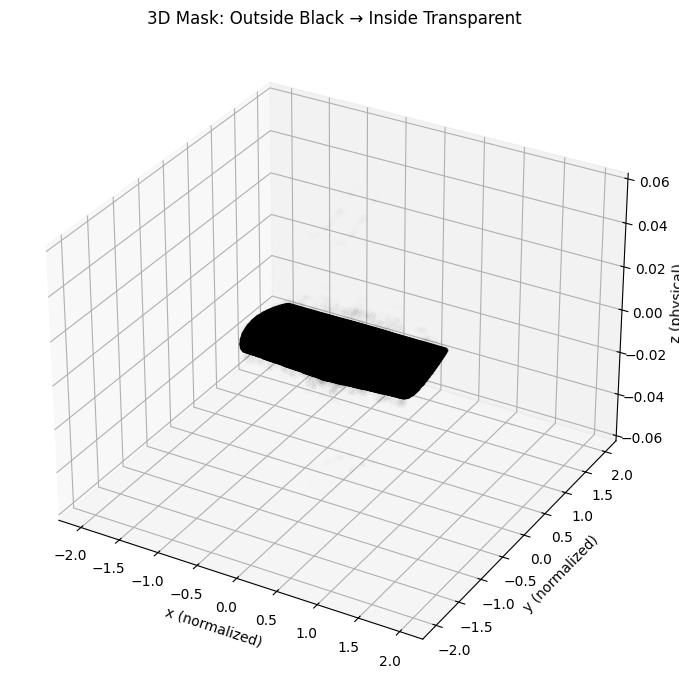

In [ ]:


# --- Invert alpha: alpha = 1 - mask ---
rgba = np.zeros((tmf.size, 4))
rgba[:, 3] = (1 - tmf).ravel()  # now inside (mask=0) → alpha=1, outside (mask→1) → alpha→0
# Min-max normalization of alpha channel (rgba[:, 3]) to [0, 1]
rgba = np.clip(rgba, 0, 1)

# Plot 3D scatter with transparency
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    ETA.ravel(), XI.ravel(), ZG.ravel(), c=rgba,marker='o', s=10
)
ax.set_xlabel('x (normalized)')
ax.set_ylabel('y (normalized)')
ax.set_zlabel('z (physical)')
ax.set_title('3D Mask: Outside Black → Inside Transparent')
ax.set_zlim(-zlim, zlim)
plt.tight_layout()
plt.show()

In [325]:
qtt_int = qtt_skcubic3d_p(qttmask, 9, eps = 1e-3, order=2)
qtt_int

TT with sizes and ranks:
N = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
R = [1, 2, 4, 8, 9, 9, 17, 17, 21, 29, 34, 62, 99, 132, 192, 233, 160, 100, 64, 41, 28, 20, 13, 9, 6, 3, 2, 1]

Device: cpu, dtype: torch.float64
#entries 316904 compression 0.002361118793487549

In [326]:
pp=9
N = 2**pp
mask_int = z_order_to_normal_nopara(qtt_int.full().cpu().numpy().ravel(),np.zeros((N,N,N)),N,N,N).T

In [327]:
eta_vals = np.linspace(-2,  2, 2**pp, endpoint=False)  # ← extended from [-1,1]
xi_ext   = np.linspace(-2,  2, 2**pp, endpoint=False)
z_vals   = np.linspace(-zlim, zlim, 2**pp, endpoint=False)

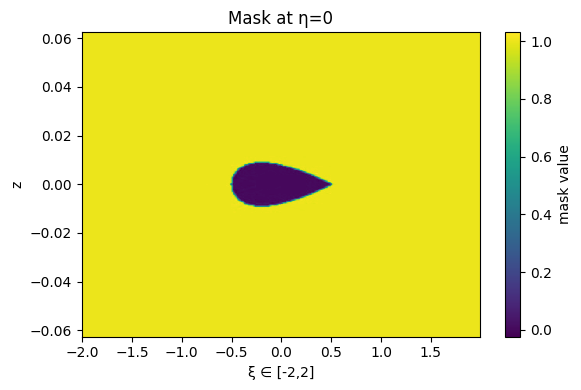

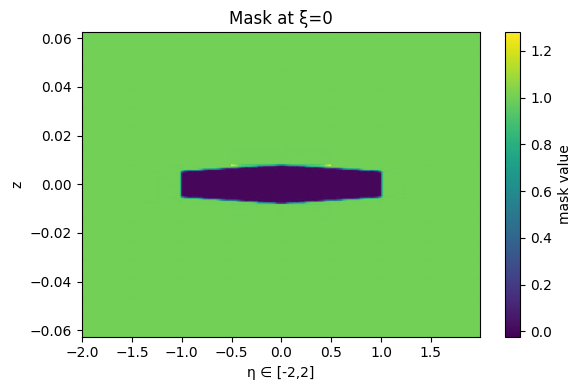

In [328]:
# η = 0 slice
i0 = np.argmin(np.abs(eta_vals - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(xi_ext, z_vals, mask_int[i0,:,:].T, shading='auto', cmap='viridis')
plt.xlabel('ξ ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at η=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()

# ξ = 0 slice
j0 = np.argmin(np.abs(xi_ext - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(eta_vals, z_vals, mask_int[:,j0,:].T, shading='auto', cmap='viridis')
plt.xlabel('η ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at ξ=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()

In [412]:

# assumes `mask` is a NumPy array
X_np = mask.astype(np.float64)              # keep high precision if you want
#X_np = np.transpose(X_np, axes=[0, 1, 2])   # your original transpose (no-op if already)
X = tn.from_numpy(X_np).to(dtype=tn.float64)

# ── HOSVD / Tucker via SVD on unfoldings ─────────────────────────────────────
def unfold_tn(X, mode):
    # move the chosen mode to the front, then flatten the rest
    return tn.movedim(X, mode, 0).reshape(X.shape[mode], -1)

def tucker_hosvd(X, ranks):
    """
    X: (I, J, K) torch tensor
    ranks: (r1, r2, r3)
    returns: core G (r1, r2, r3), factors (U1, U2, U3) with shapes (I,r1),(J,r2),(K,r3)
    """
    I, J, K = X.shape
    r1 = min(ranks[0], I)
    r2 = min(ranks[1], J)
    r3 = min(ranks[2], K)

    U = []
    for mode, r in enumerate((r1, r2, r3)):
        M = unfold_tn(X, mode)                               # (dim_mode, prod_other_dims)
        # SVD in torch
        U_mode, S_mode, Vh_mode = tn.linalg.svd(M, full_matrices=False)
        U.append(U_mode[:, :r].contiguous())                 # (dim_mode, r)

    U1, U2, U3 = U

    # Core: G = X ×1 U1^T ×2 U2^T ×3 U3^T  (einsum form)
    # X: ijk, U1^T: ai, U2^T: bj, U3^T: ck -> abc
    G = tn.einsum('ijk,ai,bj,ck->abc', X, U1.T, U2.T, U3.T)

    return G, (U1, U2, U3)

def tucker_reconstruct(G, factors):
    U1, U2, U3 = factors
    # X_hat = G ×1 U1 ×2 U2 ×3 U3  (einsum form)
    # G: abc, U1: ia, U2: jb, U3: kc -> ijk
    X_hat = tn.einsum('abc,ia,jb,kc->ijk', G, U1, U2, U3)
    return X_hat

# ── Run HOSVD/Tucker ─────────────────────────────────────────────────────────
rt = 100
G, U = tucker_hosvd(X, ranks=(rt, rt, rt))
X_hat = tucker_reconstruct(G, U)

# ── Errors ───────────────────────────────────────────────────────────────────
err_abs = tn.linalg.norm((X - X_hat).reshape(-1)).item()
err_rel = err_abs / tn.linalg.norm(X.reshape(-1)).item()

print(f"Core shape: {tuple(G.shape)}")
print(f"Abs L2 error: {err_abs:.6e}")
print(f"Rel error   : {err_rel:.6e}")


Core shape: (100, 100, 100)
Abs L2 error: 1.036572e-11
Rel error   : 2.543941e-15


In [428]:
def qttc_from_TT(ten,eps=1e-10):
    tt = tntt.TT(ten,shape = list(ten.shape) ,eps=eps)
    print(tt)
    cores = tt.cores

    comb = []
    for i in range(len(cores)):

        c = cores[i]
        rL, N, rR = c.shape
        head = c.permute(0, 2, 1).contiguous().reshape(rL*rR, N)
        p = int(np.log2(N))
        comb.append(tntt.TT(head, shape= [rL*rR]+ [2]*p, eps=eps).cores)


    return comb
            


In [457]:
comb_qtt = combqtt(G,U,eps=1e-10)
#comb_qtt = qttc_from_TT(mask)
comb_c = tree_compress_2(comb_qtt,eps=1e-8)
comp_combqtt = comb_comp(comb_qtt)
comp_combc = comb_comp(comb_c)
mrank_cqtt = comb_max_rank(comb_qtt)
print(comp_combqtt)
print(comp_combc)
print(mrank_cqtt)
#np.linalg.norm(G - tntt.TT(root).full())

0.015816688537597656
0.009536027908325195
128


In [458]:
get_R(get_roott(comb_qtt))

[1, 66, 21, 1]

In [443]:
#comb_qtt = combqtt(G,U,eps=1e-10)
comb_qtt = qttc_from_TT(mask,1e-10)
comb_c = tree_compress_2(comb_qtt,eps=1e-8)
comp_combqtt = comb_comp(comb_qtt)
comp_combc = comb_comp(comb_c)
mrank_cqtt = comb_max_rank(comb_qtt)
print(comp_combqtt)
print(comp_combc)
print(mrank_cqtt)
#np.linalg.norm(G - tntt.TT(root).full())

TT with sizes and ranks:
N = [256, 256, 256]
R = [1, 66, 21, 1]

Device: cpu, dtype: torch.float64
#entries 377088 compression 0.0224761962890625

[1, 21, 40, 40, 32, 16, 8, 4, 2, 1, 1]
[1, 68, 66, 64, 32, 16, 8, 4, 2, 1, 1]
0.010101377964019775
0.009536027908325195
128


In [447]:
comb_c = tree_compress(comb_qtt,eps=1e-5)
print(comb_comp(comb_c), comb_max_rank(comb_c))

#comb_c = tree_compress_2(comb_qtt,eps=1e-3)
#print(comb_comp(comb_c), comb_max_rank(comb_c))

0.009536027908325195 128


In [448]:
cr = combqtt_full(comb_c).numpy()
#comb = tu_to_comb(G,U,eps=1e-14)
#cr = comb_full(comb)
#print(cr.shape)


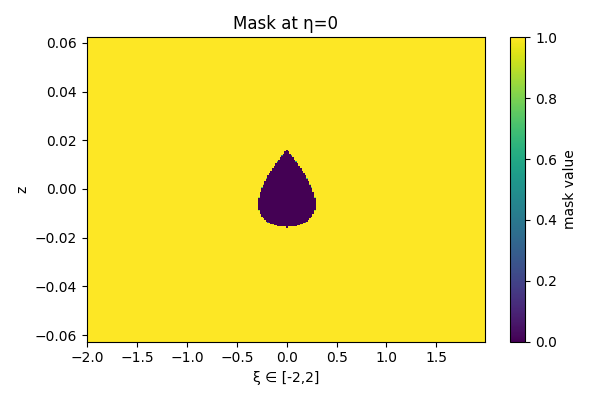

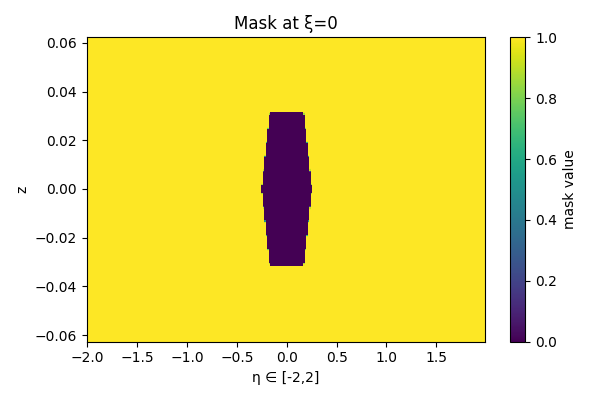

Abs L2 error: 4.415430e-07
Rel error   : 1.083629e-10


In [449]:
eta_vals = np.linspace(-2,  2, 2**8, endpoint=False)  # ← extended from [-1,1]
xi_ext   = np.linspace(-2,  2, 2**8, endpoint=False)
z_vals   = np.linspace(-zlim, zlim, 2**8, endpoint=False)
# η = 0 slice
i0 = np.argmin(np.abs(eta_vals - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(xi_ext, z_vals, cr[i0,:,:], shading='auto', cmap='viridis')
plt.xlabel('ξ ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at η=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()

# ξ = 0 slice
j0 = np.argmin(np.abs(xi_ext - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(eta_vals, z_vals, cr[:,j0,:], shading='auto', cmap='viridis')
plt.xlabel('η ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at ξ=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()


# ── Errors ───────────────────────────────────────────────────────────────────
err_abs = tn.linalg.norm((X - cr).reshape(-1)).item()
err_rel = err_abs / tn.linalg.norm(X.reshape(-1)).item()

print(f"Abs L2 error: {err_abs:.6e}")
print(f"Rel error   : {err_rel:.6e}")

In [294]:
comb = tu_to_comb(G,U,eps=1e-10)
combf_com= comb_comp(comb)
print(combf_com)
print(comb_max_rank(comb))
comb_c = tree_compress(comb,eps=1e-3)
print(comb_comp(comb_c))


0.013357400894165039
100
0.006238460540771484


0.00012974068522453308


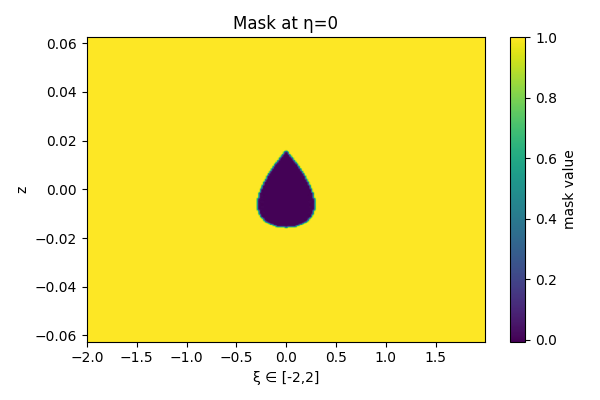

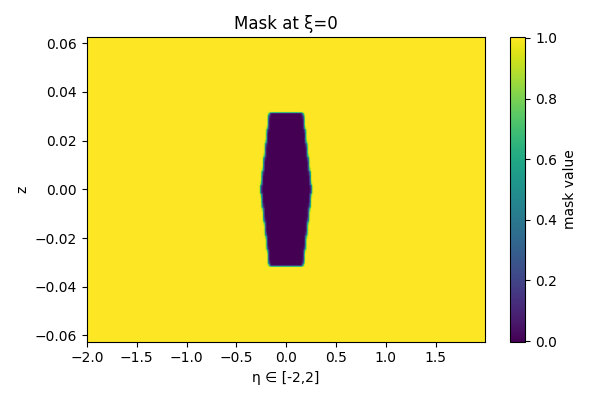

In [461]:
fd = 10 
extcqttb = comb_interpolate_p(comb_qtt,fd, eps =  1e-4,order = 2)

print(comb_comp(extcqttb))

full = combqtt_full(extcqttb).numpy()

eta_vals = np.linspace(-2,  2, 2**fd, endpoint=False)  # ← extended from [-1,1]
xi_ext   = np.linspace(-2,  2, 2**fd, endpoint=False)
z_vals   = np.linspace(-zlim, zlim, 2**fd, endpoint=False)
# η = 0 slice
i0 = np.argmin(np.abs(eta_vals - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(xi_ext, z_vals, full[i0,:,:], shading='auto', cmap='viridis')
plt.xlabel('ξ ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at η=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()

# ξ = 0 slice
j0 = np.argmin(np.abs(xi_ext - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(eta_vals, z_vals, full[:,j0,:], shading='auto', cmap='viridis')
plt.xlabel('η ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at ξ=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()



In [364]:
from time import time
for i in range(9,14):
    t1 = time()
    cmask = comb_interpolate_p(comb_qtt, i, eps =  1e-4,order = 2)
    t2 = time()
    print(f"Time for comb interp to 2**{i}: {t2-t1:.2f} sec")
    print("\033[91m" + str(i) + ", " + f"{comb_comp(cmask):.3e}" + " , " + str(comb_max_rank(cmask)) + "\033[0m")

    t1 = time()
    zmask = qtt_skcubic3d_p(qttmask, i, eps = 1e-4, order=2)
    t2 = time()
    print(f"Time for QTT interp to 2**{i}: {t2-t1:.2f} sec")
    print("\033[94m" + str(i) + ", " + f"{tt_comp(zmask):.3e}" + " , " + str(np.max(zmask.R)) + "\033[0m")

Time for comb interp to 2**9: 0.55 sec
9, 1.031e-03 , 107
Time for QTT interp to 2**9: 19.38 sec
9, 7.178e-03 , 400
Time for comb interp to 2**10: 0.28 sec
10, 1.297e-04 , 107
Time for QTT interp to 2**10: 22.32 sec
10, 1.029e-03 , 415
Time for comb interp to 2**11: 0.30 sec
11, 1.625e-05 , 108
Time for QTT interp to 2**11: 24.22 sec
11, 1.362e-04 , 423
Time for comb interp to 2**12: 0.30 sec
12, 2.037e-06 , 108
Time for QTT interp to 2**12: 24.37 sec
12, 1.738e-05 , 426
Time for comb interp to 2**13: 0.30 sec
13, 2.546e-07 , 108
Time for QTT interp to 2**13: 25.15 sec
13, 2.231e-06 , 429


In [ ]:
qtt_R_max = int(np.round(np.max(qttmask.R)))
qtt_erank = int(np.round(erank(qttmask.R, qttmask.N)))
qtt_comp  = tt_comp(qttmask)
tt_R_max   = int(np.round(np.max(ttmask.R)))
tt_erank   = int(np.round(erank(ttmask.R, ttmask.N)))
tt_com   = tt_comp(ttmask)

# Use ANSI escape sequences to color the outputs (red for qtt, blue for tt)
print("\033[91mqtt_R_max =", qtt_R_max, "\033[0m")
print("\033[91mqtt_erank =", qtt_erank, "\033[0m")
print("\033[91mqtt_comp  =", qtt_comp, "\033[0m")
print("\033[94mtt_R_max =", tt_R_max, "\033[0m")
print("\033[94mtt_erank =", tt_erank, "\033[0m")
print("\033[94mtt_comp  =", tt_com, "\033[0m")

print("\033[92mmrank_cqtt =", mrank_cqtt, "\033[0m")
print("\033[92mcomp_combqtt =", comp_combqtt, "\033[0m")

print("\033[95mcombf_com =", combf_com, "\033[0m")



qtt_R_max = 290 
qtt_erank = 93 
qtt_comp  = 0.022902727127075195 
tt_R_max = 217 
tt_erank = 125 
tt_comp  = 0.04075026512145996 
mrank_cqtt = 128 
comp_combqtt = 0.015816688537597656 
combf_com = 0.013357400894165039 


In [6]:
%cd ..

c:\Users\siddhartha.morales\OneDrive - Technology Innovation Institute\Documents\GitHub\QTT-polynomial-interpolation\src


In [ ]:
from qtt_interpolation.utils import *
from qtt_interpolation.int_tools import *
import teneva as ten
import numpy as np
from time import time


# --- Wing parameterization ---
b, c_r, c_t = 2.0, 1.0, 0.5
Lambda_LE = np.deg2rad(15)
phi       = 0.0
t_chord        = 0.12

def chord(eta):
    return c_r*(1 - np.abs(eta))/2 + c_t*(1 + np.abs(eta))/2

def z_planform(eta):
    return 0.5 * b * eta * np.tan(phi)

def y_t(xi):
    return t_chord*(0.2969 * np.sqrt(xi)
             - 0.1260 * xi
             - 0.3516 * xi**2
             + 0.2843 * xi**3
             - 0.1015 * xi**4)



def wing_mask(ETA, XI, ZG, alpha=1000.0):
    """
    Build the 3D wing mask on given grids (exactly mirrors the reference code).

    ETA, XI, ZG : same-shaped ndarrays from meshgrid(indexing='ij'), i.e.
                  ETA = eta-grid, XI = xi-grid, ZG = z-grid
    alpha       : falloff factor (use 1000.0 to match reference)

    Returns
    -------
    mask : torch tensor (float64) with same shape as ZG
           =0 inside wing, transitions to 1 outside
    """
    # --- chordwise band in [-0.5, 0.5] over xi (XI) ---
    mask_band = (XI[:, :, 0] >= -0.5) & (XI[:, :, 0] <= 0.5)

    # --- 2D upper/lower surfaces (z at the band) ---
    Zup2d  = np.zeros_like(ETA[:, :, 0], dtype=np.float64)
    Zlow2d = np.zeros_like(ETA[:, :, 0], dtype=np.float64)

    xi_param = XI[:, :, 0][mask_band] + 0.5   # map [-0.5,0.5] → [0,1]
    eta_m    = ETA[:, :, 0][mask_band]

    # chord(), y_t(), z_planform() are assumed globally defined
    C_m = chord(eta_m)
    Zt  = C_m * y_t(xi_param)

    Zup2d[mask_band]  = z_planform(eta_m) + Zt
    Zlow2d[mask_band] = z_planform(eta_m) - Zt

    # --- Broadcast to 3D (use the same form as your script) ---
    Zup3d  = Zup2d[:, :, None]  * np.ones_like(ZG, dtype=np.float64)
    Zlow3d = Zlow2d[:, :, None] * np.ones_like(ZG, dtype=np.float64)

    # --- Thickness scale (exactly as in your script) ---
    xi_test    = np.linspace(0.0, 1.0, 1000)
    max_y_t    = np.max(y_t(xi_test))
    c_root     = chord(0.0)
    real_thick = 2.0 * c_root * max_y_t

    # --- Initialize mask to 1 everywhere (float64) ---
    mask = np.ones_like(ZG, dtype=np.float64)

    # --- Core region in eta/xi (2D, then lift to 3D) ---
    mask_eta  = (ETA[:, :, 0] >= -1.0) & (ETA[:, :, 0] <= 1.0)
    mask_xi   = (XI[:,  :, 0] >= -1.0) & (XI[:,  :, 0] <= 1.0)
    mask_core = mask_eta & mask_xi

    core3d = mask_core[:, :, None]
    band3d = mask_band[:, :, None]

    # 1) Inside wing → mask = 0
    inside = core3d & band3d & (ZG >= Zlow3d) & (ZG <= Zup3d)
    mask[inside] = 0.0

    # 2) Above upper surface → exponential falloff
    above = core3d & band3d & (ZG > Zup3d)

    zd_above = ZG - Zup3d
    mask[above] = 1.0 - np.exp(-(alpha/real_thick) * zd_above[above])

    # 3) Below lower surface → exponential falloff
    below = core3d & band3d & (ZG < Zlow3d)

    zd_below = Zlow3d - ZG
    mask[below] = 1.0 - np.exp(-(alpha/real_thick) * zd_below[below])

    # torch output to match your downstream code
    return tn.tensor(mask, dtype=tn.float64)

def wing_mask_pc(x, y, z, alpha=1000.0):
    """
    Pointwise wing mask.

    x, y, z : 1D arrays/lists of the same length (eta, xi, z per point)
    alpha   : sharpness of exponential falloff

    Returns
    -------
    mask : 1D torch tensor with values in [0,1]
           0 inside the wing; transitions to 1 outside.
    """
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    y = np.asarray(y, dtype=np.float64).reshape(-1)
    z = np.asarray(z, dtype=np.float64).reshape(-1)
    assert x.shape == y.shape == z.shape, "x, y, z must have the same shape"

    n = x.size
    mask = np.ones(n, dtype=np.float64)

    # core region in eta/xi and chordwise band
    in_core = (x >= -1.0) & (x <= 1.0) & (y >= -1.0) & (y <= 1.0)
    in_band = (y >= -0.5) & (y <= 0.5)
    use     = in_core & in_band
    if not np.any(use):
        return tn.tensor(mask, dtype=tn.float64)  # all ones

    # thickness normalization
    xi_test    = np.linspace(0.0, 1.0, 1000)
    real_thick = 2.0 * float(chord(0.0)) * float(np.max(y_t(xi_test)))
    if real_thick <= 0.0:
        return tn.tensor(mask, dtype=tn.float64)

    # compute local upper/lower surfaces only for selected points
    eta_u   = x[use]
    xi_u    = y[use]
    xi_par  = xi_u + 0.5                  # map [-0.5,0.5] → [0,1]
    C_u     = chord(eta_u)
    Zt_u    = C_u * y_t(xi_par)
    zc_u    = z_planform(eta_u)
    zup_u   = zc_u + Zt_u
    zlow_u  = zc_u - Zt_u
    z_u     = z[use]

    # inside
    inside_u = (z_u >= zlow_u) & (z_u <= zup_u)
    mask[use] = np.where(inside_u, 0.0, mask[use])

    # above
    above_u = z_u > zup_u
    if np.any(above_u):
        dz = z_u[above_u] - zup_u[above_u]
        mask[use][above_u] = 1.0 - np.exp(-(alpha/real_thick) * dz)

    # below
    below_u = z_u < zlow_u
    if np.any(below_u):
        dz = zlow_u[below_u] - z_u[below_u]
        mask[use][below_u] = 1.0 - np.exp(-(alpha/real_thick) * dz)

    return mask

def ind_to_r_g(I, a, b, d=3, pdp=1, dtype=np.float64):
    """
    This function maps a multi-digit index to a real number in [a, b)^d.
    Each entry in I[k] is an integer in 0,...,2**pdp-1 and is expanded to its binary representation.
    The resulting binary digits are concatenated to form a long vector of 0's and 1's for each sample.
    Returns a numpy array of shape (num_samples, d).
    """
    I = np.asarray(I)
    num_samples = I.shape[0]
    l = I.shape[1]*pdp  # total number of binary digits per sample
    # Convert each entry to binary and concatenate
    I_bin = ((I[..., None] >> np.arange(pdp-1, -1, -1)) & 1).reshape(num_samples, -1)
    powers = np.array([2**(-i) for i in range(1, l//d+1)])
    result = np.empty((num_samples, d))
    for j in range(d):
        idx = np.arange(j, l, d)
        group = I_bin[:, idx]
        wI = group * powers
        x = (b[j] - a[j]) * wI.sum(axis=1) + a[j]
        result[:, j] = x

    return result


def ften3d(I,a,b):
    X = ind_to_r_g(I,a=a,b=b,d=3,pdp=1)
    x,y,z = X[:,0], X[:,1], X[:,2]
    return wing_mask_pc( tn.tensor(x,dtype=tn.float64), tn.tensor(y,dtype=tn.float64),tn.tensor(z,dtype=tn.float64))

f = lambda I : ften3d(I,a=[-2,-2,-zlim],b=[2,2,zlim])

#------------------

p_coarse = 5
zlim     = 1/16
num_points = 2**p_coarse
pmax = 6
reps = 1
mode = []
scale  = []
error = []
T= []
rmax, ernk = [], []

for p in range(p_coarse+1, pmax+1):


    print(p,pmax, flush=True)
    #get statistics for cross
    for i in range(reps):

        # SVD coarse interleaved
        t = time()
        x = np.linspace(-2,  2, 2**p_coarse, endpoint=False)  # ← extended from [-1,1]
        y   = np.linspace(-2,  2, 2**p_coarse, endpoint=False)
        z   = np.linspace(-zlim, zlim, 2**p_coarse, endpoint=False)
        X, Y, Z = np.meshgrid(x, y,z, indexing='ij')

        mask_grid = wing_mask(X,Y,Z)
        mask_svd = tntt.TT(zM3(mask_grid,p_coarse),[2,2,2]*p_coarse,eps=1e-10)
        t_mask = time() - t

        # TT cross interleaved
        ncoarse = [ 2,2,2]*p_coarse
        m         = None  # Number of calls to target function
        e         =  1e-7   # Desired accuracy
        nswp      = 3   # Sweep number
        r         = 30      # TT-rank of the initial tensor
        dr_min    = 2      # Cross parameter (minimum number of added rows)
        dr_max    = 5      # Cross parameter (maximum number of added rows)

        
        Yc = ten.rand(ncoarse, r)
        cache,info_coarse = {}, {}
        mask_ttc = ten.cross(f, Yc, m, e, nswp, dr_min=dr_min, dr_max=dr_max,log=True,cache=cache,m_cache_scale=5,info=info_coarse)
        mask_ttc = ten.truncate(mask_ttc,1e-12)

        # do the interpolation
        t = time()
        mask_svd_i = qtt_skcubic3d_p(mask_svd, p, eps = 1e-3, order=2)
        t_svd_i = time() - t
        mask_svd_i = [c.numpy() for c in mask_svd_i.cores]

        t = time()
        mask_ttc_i = qtt_skcubic3d_p( tntt.TT([tn.tensor(c,dtype=tn.float64) for c in mask_ttc]) ,p, eps=1e-3, order=2)
        t_ttc_i = time() - t
        mask_ttc_i = [c.numpy() for c in mask_ttc_i.cores]

        #cross over the fine grid

        n = [ 2,2,2]*p   # Shape of the tensor
        m         = None  # Number of calls to target function
        e         =  1e-7   # Desired accuracy
        nswp      = 3   # Sweep number
        r         = 30 + (p-p_coarse)*2      # TT-rank of the initial tensor
        dr_min    = 2      # Cross parameter (minimum number of added rows)
        dr_max    = 5      # Cross parameter (maximum number of added rows)

        Y = ten.rand(n, r)
        info_fine,cache = {}, {}
        Y = ten.cross(f, Y, m, e, nswp, dr_min=dr_min, dr_max=dr_max, cache=cache,m_cache_scale=5,log=True,info=info_fine)
        Yr = ten.truncate(Y, 1e-3) 

        ''' 
        #validate over 1e5 points
        m_tst = int(1e5)
        # Random multi-indices for the test points:
        I_tst = np.vstack([np.random.choice(k, m_tst) for k in n]).T
        y_tst = f(I_tst)
        norm = np.linalg.norm(y_tst)

        y_tt = ten.get_many(Yr, I_tst)
        e_tst = np.linalg.norm(y_tt - y_tst) / norm

        y_tti = ten.get_many(mask_ttc_i, I_tst)
        e_tstti = np.linalg.norm(y_tti - y_tst) / norm
    
        y_tti_svd = ten.get_many(mask_svd_i, I_tst)
        e_tstti_svd = np.linalg.norm(y_tti - y_tst) / norm
        print('errors', e_tst,e_tstti,e_tstti_svd)
        '''
        print('doing errors...',flush=True)
        N = 2**p
        x = np.linspace(-2,  2, 2**p, endpoint=False)  # ← extended from [-1,1]
        y   = np.linspace(-2,  2, 2**p, endpoint=False)
        z   = np.linspace(-zlim, zlim, 2**p, endpoint=False)
        X, Y, Z = np.meshgrid(x, y,z, indexing='ij')
        mask_grid = wing_mask(X,Y,Z)
        mask_full = zM3(mask_grid,p)
        norm = tn.linalg.norm(mask_grid)


        y_tt = tntt.TT( [tn.tensor(c,dtype=tn.float64) for c in Yr] ).full().reshape(N,N,N)
        e_tst = tn.linalg.norm(mask_full - y_tt) / norm

        y_tti = tntt.TT( [tn.tensor(c,dtype=tn.float64) for c in mask_ttc_i] ).full().reshape(N,N,N)
        e_tstti = tn.linalg.norm(mask_full - y_tti) / norm
    
        y_tti_svd = tntt.TT( [tn.tensor(c,dtype=tn.float64) for c in mask_svd_i] ).full().reshape(N,N,N)
        e_tstti_svd = tn.linalg.norm(mask_full - y_tti_svd) / norm

        # Save only the last 3 entries: 'cross', 'cross_int', 'svd_int'
        mode.extend(['cross', 'cross_int', 'svd_int'])
        scale.extend([p, p, p])
        error.extend([e_tst.item(), e_tstti.item(), e_tstti_svd.item()])
        T.extend([info_fine['t'], t_ttc_i + info_coarse['t'], t_svd_i + t_mask])
        rmax.extend([
            np.max(ten.ranks(Yr)),
            np.max(ten.ranks(mask_ttc_i)),
            np.max(ten.ranks(mask_svd_i))
        ])
        ernk.extend([
            ten.erank(Yr),
            ten.erank(mask_ttc_i),
            ten.erank(mask_svd_i)
        ])

        print((i+1)/reps, end='\r', flush=True)

        # Save the last 3 rows as JSON lines
        for j in range(-3, 0):
            raw_row = {
            'method': mode[j],
            'scale':  scale[j],
            'error':  error[j],
            'time':   T[j],
            'rmax':   rmax[j],
            'erank':  ernk[j]
            }
            # Convert any Tensor or NumPy scalar to plain Python

            ''' 
            safe_row = {}
            for k, v in raw_row.items():
                if isinstance(v, tn.Tensor):
                    safe_row[k] = v.item() if v.numel() == 1 else v.tolist()
                elif isinstance(v, np.generic):
                    safe_row[k] = v.item()
                else:
                    safe_row[k] = v

            with open(jsonl_path, 'a') as f:
                f.write(json.dumps(safe_row) + '\n')
                f.flush()
                os.fsync(f.fileno())
            '''

        print(f"  rep {i+1}/{reps} saved", end='\r', flush=True)

6 6
0.012003444536256099 0.75
Approximate max thickness at root chord: 0.01800516680438415
# pre | time:      0.013 | evals: 0.00e+00 (+ 0.00e+00) | rank:  30.0 | 
#   1 | time:      0.866 | evals: 9.79e+03 (+ 1.65e+04) | rank:  24.1 | e: 1.0e+00 | 
#   2 | time:      2.222 | evals: 1.33e+04 (+ 4.59e+04) | rank:  27.3 | e: 4.9e-02 | 
#   3 | time:      4.556 | evals: 1.54e+04 (+ 8.50e+04) | rank:  30.2 | e: 1.8e-02 | stop: conv | 
# pre | time:      0.030 | evals: 0.00e+00 (+ 0.00e+00) | rank:  32.0 | 
#   1 | time:      1.889 | evals: 1.79e+04 (+ 2.77e+04) | rank:  29.4 | e: 1.0e+00 | 
#   2 | time:      5.430 | evals: 2.78e+04 (+ 8.01e+04) | rank:  34.0 | e: 4.1e-02 | 
#   3 | time:     11.314 | evals: 3.69e+04 (+ 1.53e+05) | rank:  38.6 | e: 1.2e-02 | stop: nswp | 
doing errors...
0.012003444536256099 0.75
Approximate max thickness at root chord: 0.01800516680438415


In [49]:
import pandas as pd
df = pd.DataFrame({
    'method': mode,
    'scale': scale,
    'error': error,
    'time': T,
    'rmax': rmax,
    'erank': ernk
})
df

,method,scale,error,time,rmax,erank
0,cross,6,0.127378,11.313872,51,22.765748
1,cross_int,6,0.115205,4.687870,39,22.025481
2,svd_int,6,0.040037,0.201749,38,20.396396


# pre | time:      0.018 | evals: 0.00e+00 (+ 0.00e+00) | rank:  32.0 | 
#   1 | time:      1.662 | evals: 1.71e+04 (+ 2.66e+04) | rank:  28.4 | e: 1.0e+00 | 
#   2 | time:      4.465 | evals: 2.78e+04 (+ 7.44e+04) | rank:  32.8 | e: 6.1e-02 | 
#   3 | time:      9.969 | evals: 3.60e+04 (+ 1.43e+05) | rank:  37.3 | e: 4.4e-02 | stop: nswp | 


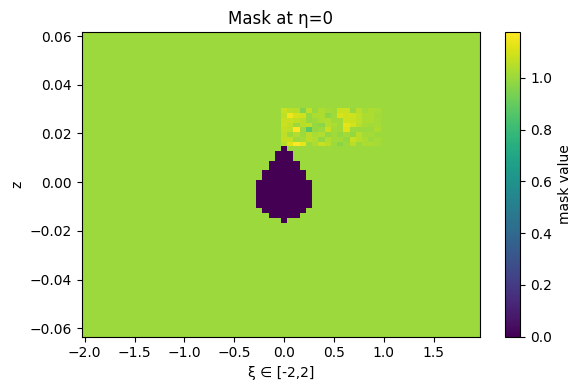

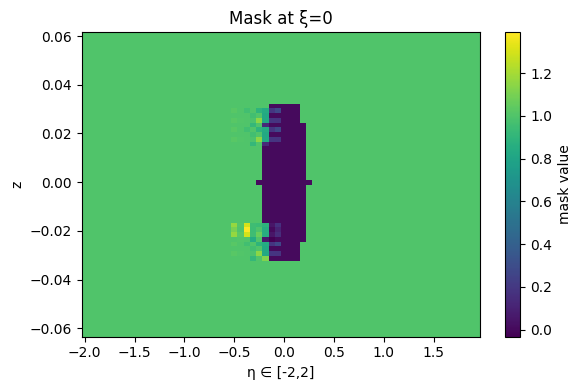

In [50]:
fd = p

eta_vals = np.linspace(-2,  2, 2**fd, endpoint=False)  # ← extended from [-1,1]
xi_ext   = np.linspace(-2,  2, 2**fd, endpoint=False)
z_vals   = np.linspace(-zlim, zlim, 2**fd, endpoint=False)

n = [ 2,2,2]*p   # Shape of the tensor
m         = None  # Number of calls to target function
e         =  1e-8   # Desired accuracy
nswp      = 3   # Sweep number
r         = 30 + (p-p_coarse)*2      # TT-rank of the initial tensor
dr_min    = 2      # Cross parameter (minimum number of added rows)
dr_max    = 5      # Cross parameter (maximum number of added rows)

Y = ten.rand(n, r)
info_fine,cache = {}, {}
Y = ten.cross(f, Y, m, e, nswp, dr_min=dr_min, dr_max=dr_max, cache=cache,m_cache_scale=5,log=True,info=info_fine)
Yr = ten.truncate(Y, 1e-5) 
y_tt = tntt.TT( [tn.tensor(c,dtype=tn.float64) for c in Yr] ).full().reshape(N,N,N)

mf = z_order_to_normal_torch_3d(y_tt.flatten(),2**p,2**p,2**p).to(dtype=tn.float64)
#mf = mask_grid
#X, Y, Z = np.meshgrid(eta_vals, xi_ext,z_vals, indexing='ij')
#mf = wing_mask(X,Y,Z)

# η = 0 slice
i0 = np.argmin(np.abs(eta_vals - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(xi_ext, z_vals, mf[i0,:,:], shading='auto', cmap='viridis')
plt.xlabel('ξ ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at η=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()

# ξ = 0 slice
j0 = np.argmin(np.abs(xi_ext - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(eta_vals, z_vals, mf[:,j0,:], shading='auto', cmap='viridis')
plt.xlabel('η ∈ [-2,2]')
plt.ylabel('z')
plt.title('Mask at ξ=0')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()



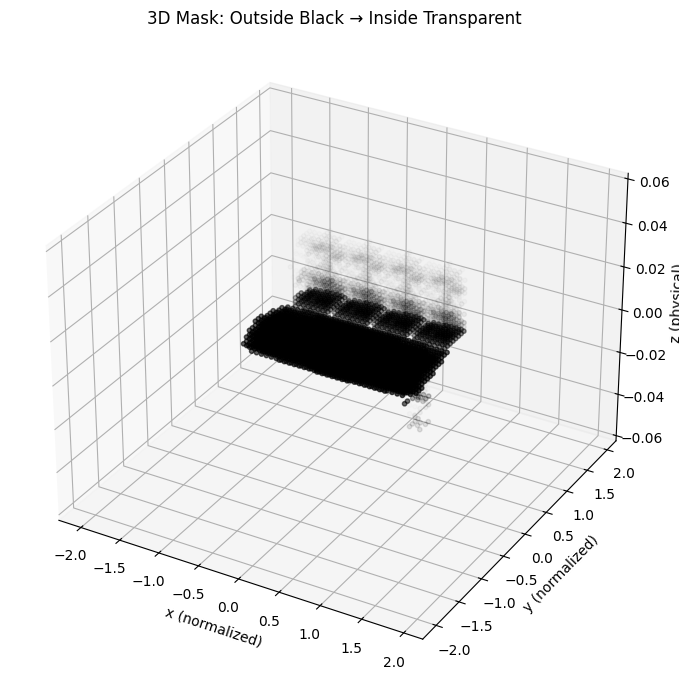

In [51]:
x = np.linspace(-2,  2, 2**p, endpoint=False)  # ← extended from [-1,1]
y   = np.linspace(-2,  2, 2**p, endpoint=False)
z   = np.linspace(-zlim, zlim, 2**p, endpoint=False)
X, Y, Z = np.meshgrid(x, y,z, indexing='ij')
rgba = np.zeros((mf.numpy().size, 4))
rgba[:, 3] = (1 - mf).ravel()  # now inside (mask=0) → alpha=1, outside (mask→1) → alpha→0
rgba = np.clip(rgba, 0, 1)
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    X.ravel(), Y.ravel(), Z.ravel(), c=rgba,marker='o', s=10
)
ax.set_xlabel('x (normalized)')
ax.set_ylabel('y (normalized)')
ax.set_zlabel('z (physical)')
ax.set_title('3D Mask: Outside Black → Inside Transparent')
ax.set_zlim(-zlim, zlim)
plt.tight_layout()
plt.show()

In [27]:
mask_grid.shape

torch.Size([64, 64, 64])

In [18]:
mask_full.shape

torch.Size([64, 64, 64])

## Model 2

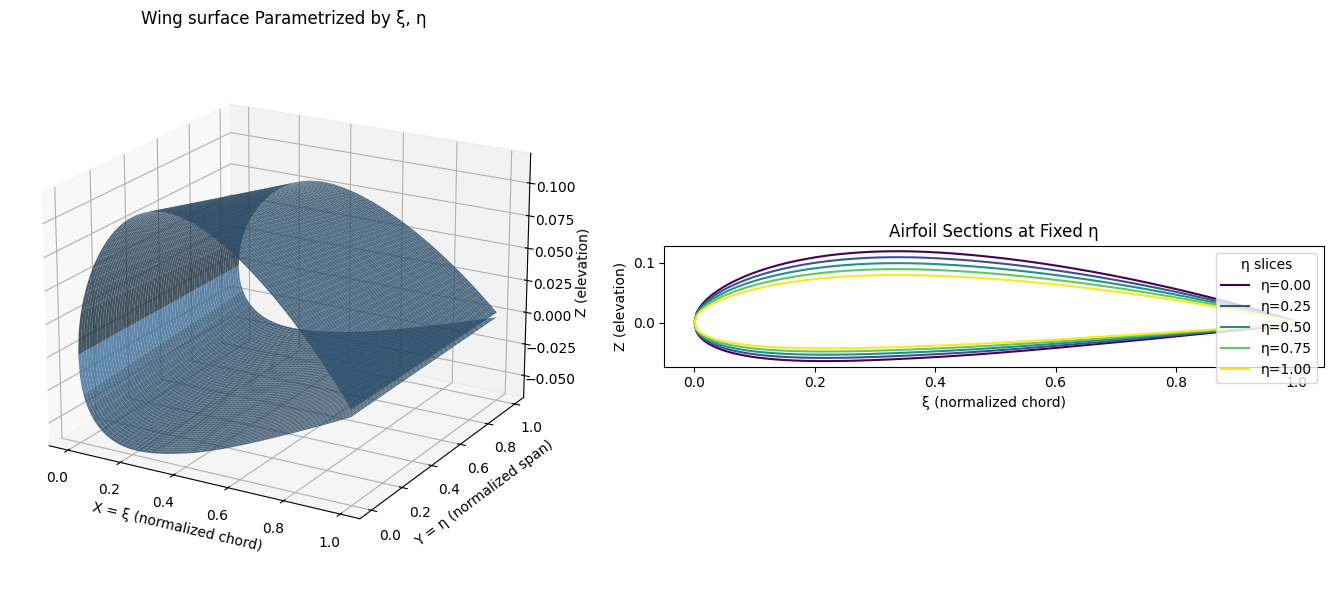

In [249]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ─── Wing parameters ───────────────────────────────────────────────────────────
b, c_r, c_t    = 10.0, 2.0, 1.0      # span, root & tip chord (unused in X,Y here)
Lambda_LE      = np.deg2rad(25)      # sweep (unused in X,Y here)
m, p_cam, t    = 0.02, 0.4, 0.12     # camber & thickness parameters

def chord(eta):
    return c_r * (1 - eta)/2 + c_t * (1 + eta)/2

def thickness_dist(xi):
    return 5*t * (
        0.2969*np.sqrt(xi)
        -0.1260*xi
        -0.3516*xi**2
        +0.2843*xi**3
        -0.1015*xi**4
    )

def camber_line(xi):
    yc = np.where(
        xi < p_cam,
        m/(p_cam**2)*(2*p_cam*xi - xi**2),
        m/((1-p_cam)**2)*((1-2*p_cam) + 2*p_cam*xi - xi**2)
    )
    dyc = np.where(
        xi < p_cam,
        2*m/(p_cam**2)*(p_cam - xi),
        2*m/((1-p_cam)**2)*(p_cam - xi)
    )
    return yc, dyc

# ─── Grid definition ──────────────────────────────────────────────────────────
p = 8
N = 2**p

# ξ, η ∈ [0,1), endpoint=False
xi_vals  = np.linspace(0.0, 1.0, N, endpoint=False)
eta_vals = np.linspace(0.0, 1.0, N, endpoint=False)

# 2D parametric grid: XI along X, ETA along Y
XI, ETA = np.meshgrid(xi_vals, eta_vals, indexing='ij')

# ─── Compute camber & thickness in 2D ────────────────────────────────────────
C      = chord(ETA)               # chord length (for scaling Z)
yc, _  = camber_line(XI)          # camber fraction
yt     = thickness_dist(XI)       # half-thickness fraction

# ─── Embed in 3D: X=ξ, Y=η, Z=surface elevation ─────────────────────────────
X       = XI
Y       = ETA

Z_upper = yc*C + yt*C
Z_lower = yc*C - yt*C

# ─── Plot the 3D wing surface ───────────────────────────────────────────────
fig = plt.figure(figsize=(14,6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, Y, Z_upper, rstride=4, cstride=4, color='steelblue', alpha=0.8)
ax1.plot_surface(X, Y, Z_lower, rstride=4, cstride=4, color='steelblue', alpha=0.8)
ax1.set_xlabel('X = ξ (normalized chord)'); ax1.set_ylabel('Y = η (normalized span)')
ax1.set_zlabel('Z (elevation)')
ax1.set_title('Wing surface Parametrized by ξ, η')
ax1.view_init(elev=20, azim=-60)

# ─── Plot airfoil sections at constant η slices ──────────────────────────────
ax2 = fig.add_subplot(122)
eta_slices = [0.0, 0.25, 0.5, 0.75, 1.0]
colors     = plt.cm.viridis(np.linspace(0,1,len(eta_slices)))
for η, col in zip(eta_slices, colors):
    j = np.argmin(np.abs(eta_vals - η))
    ax2.plot(xi_vals, Z_upper[:, j], color=col)
    ax2.plot(xi_vals, Z_lower[:, j], color=col, label=f'η={η:.2f}')

ax2.set_aspect('equal')
ax2.set_xlabel('ξ (normalized chord)')
ax2.set_ylabel('Z (elevation)')
ax2.set_title('Airfoil Sections at Fixed η')
ax2.legend(title='η slices', loc='upper right')

plt.tight_layout()
plt.show()


C:\Users\siddhartha.morales\AppData\Local\Temp\ipykernel_20288\1677919756.py:13: RuntimeWarning: invalid value encountered in sqrt
  return 5*t*(0.2969*np.sqrt(xi)


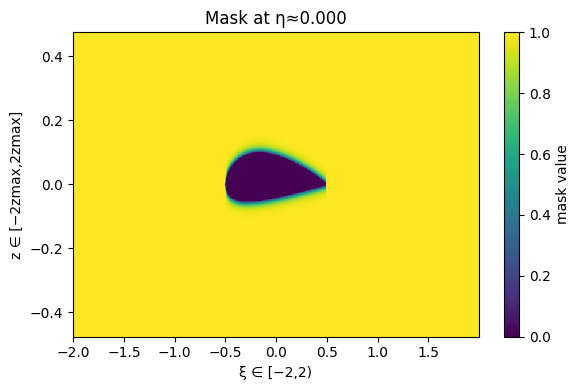

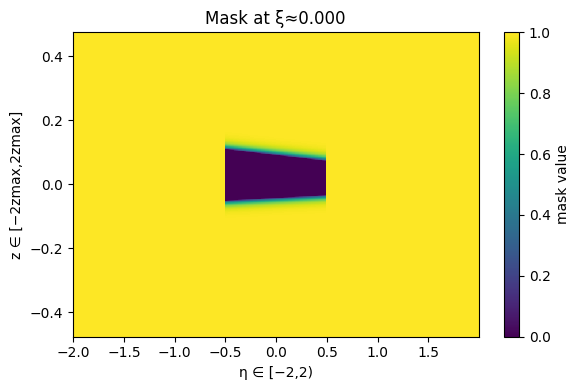

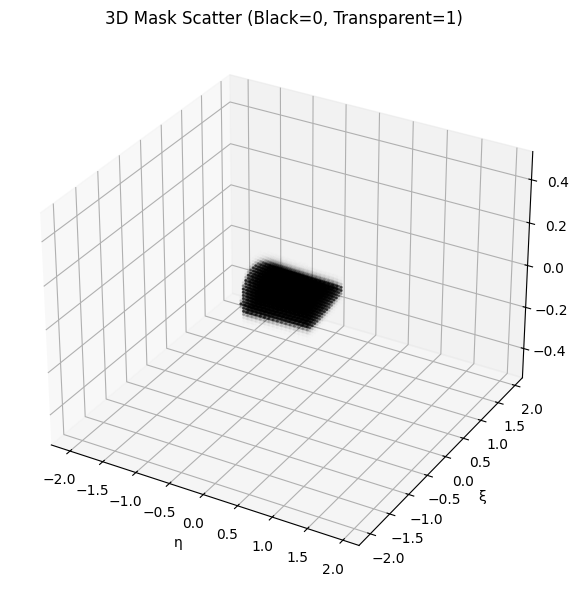

In [250]:
import numpy as np
import matplotlib.pyplot as plt

# ─── Wing parameters ─────────────────────────────────────────────────────────
b, c_r, c_t = 10.0, 2.0, 1.0
Lambda_LE   = np.deg2rad(25)
m, p_cam, t = 0.02, 0.4, 0.12

def chord(eta):
    return c_r*(1 - eta)/2 + c_t*(1 + eta)/2

def thickness_dist(xi):
    return 5*t*(0.2969*np.sqrt(xi)
                -0.1260*xi
                -0.3516*xi**2
                +0.2843*xi**3
                -0.1015*xi**4)

def camber_line(xi):
    yc = np.where(xi < p_cam,
                  m/(p_cam**2)*(2*p_cam*xi - xi**2),
                  m/((1-p_cam)**2)*((1-2*p_cam) + 2*p_cam*xi - xi**2))
    return yc, None

# ─── 1) Compute z_max on the original [0,1)×[0,1) grid ─────────────────────
p = 9
N = 2**p

eta_core = np.linspace(0.0, 1.0, N, endpoint=False)
xi_core  = np.linspace(0.0, 1.0, N, endpoint=False)
ETA2, XI2 = np.meshgrid(eta_core, xi_core, indexing='ij')

C2     = chord(ETA2)
yc2, _ = camber_line(XI2)
yt2    = thickness_dist(XI2)

Zup2   = yc2*C2 + yt2*C2
Zlow2  = yc2*C2 - yt2*C2

zmax = np.max(np.abs([Zup2, Zlow2]))

# ─── 2) Build the extended grid η,ξ ∈ [−2,2), z ∈ [−2zmax,2zmax) ─────────────
eta_vals = np.linspace(-2.0, 2.0, N, endpoint=False)
xi_vals  = np.linspace(-2.0, 2.0, N, endpoint=False)
z_vals   = np.linspace(-4*zmax, 4*zmax, N, endpoint=False)

ETA3, XI3, ZG = np.meshgrid(eta_vals, xi_vals, z_vals, indexing='ij')

# ─── 3) Map extended coords back to “core” params and gate core region ───────
eta_mapped = ETA3 + 0.5   # now [−2,2)→[−1.5,2.5); core is [0,1)
xi_mapped  = XI3  + 0.5   # same
core_mask  = (
    (eta_mapped >= 0) & (eta_mapped < 1) &
    (xi_mapped  >= 0) & (xi_mapped  < 1)
)

# ─── 4) Compute wing surfaces at those mapped params ─────────────────────────
C3      = chord(eta_mapped)
yc3, _  = camber_line(xi_mapped)
yt3     = thickness_dist(xi_mapped)

Zup3    = yc3*C3 + yt3*C3
Zlow3   = yc3*C3 - yt3*C3

# ─── 5) Build the embedded mask ──────────────────────────────────────────────
mask = np.ones_like(ZG)

# inside wing → 0
inside = core_mask & (ZG >= Zlow3) & (ZG <= Zup3)
mask[inside] = 0.0

# above wing → 1 − exp(−100·Δz)
above = core_mask & (ZG > Zup3)
mask[above] = 1.0 - np.exp(-100.0 * (ZG[above] - Zup3[above]))

# below wing → 1 − exp(−100·Δz)
below = core_mask & (ZG < Zlow3)
mask[below] = 1.0 - np.exp(-100.0 * (Zlow3[below] - ZG[below]))

# ─── 6) Visualize central η‐slice and central ξ‐slice ────────────────────────
i_eta0 = np.argmin(np.abs(eta_vals - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(xi_vals, z_vals, mask[i_eta0,:,:].T, shading='auto')
plt.xlabel('ξ ∈ [−2,2)')
plt.ylabel('z ∈ [−2zmax,2zmax]')
plt.title(f'Mask at η≈{eta_vals[i_eta0]:.3f}')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()

j_xi0 = np.argmin(np.abs(xi_vals - 0.0))
plt.figure(figsize=(6,4))
plt.pcolormesh(eta_vals, z_vals, mask[:,j_xi0,:].T, shading='auto')
plt.xlabel('η ∈ [−2,2)')
plt.ylabel('z ∈ [−2zmax,2zmax]')
plt.title(f'Mask at ξ≈{xi_vals[j_xi0]:.3f}')
plt.colorbar(label='mask value')
plt.tight_layout()
plt.show()

# ─── 7) 3D scatter of mask values ────────────────────────────────────────────
# Downsample for performance
step = 8
X_s = ETA3[::step, ::step, ::step].flatten()
Y_s = XI3[::step, ::step, ::step].flatten()
Z_s = ZG[::step, ::step, ::step].flatten()
m_s = mask[::step, ::step, ::step].flatten()

# RGBA: black when mask=0, transparent when mask=1
colors = np.zeros((m_s.size, 4))
colors[:, 3] = 1.0 - m_s  # alpha channel

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_s, Y_s, Z_s, color=colors, s=2)
ax.set_xlabel('η')
ax.set_ylabel('ξ')
ax.set_zlabel('z')
ax.set_title('3D Mask Scatter (Black=0, Transparent=1)')
plt.tight_layout()
plt.show()


In [251]:


m = tn.tensor(mask, dtype=tn.float64)
#m = tn.permute(m, (0, 1, 2))  # ensure shape is (N, N, N)
twing = tntt.TT(zM3(m,p), [2,2,2]*p,eps=1e-3)

np.max(twing.R)

101

In [53]:
tnmask = tn.tensor(mask,dtype=tn.float64)
tz = tn.zeros_like(tnmask)
x_order = bit_reverse_indices(p)
for i in range(2**p):
    tz[i,:,:] = zM(tnmask[i,:,:],p)
tz = tz[x_order,:,:]
ttmask = tntt.TT(tz,[2]*p+[2,2]*p,eps=1e-3)
print(np.max(ttmask.R))


69


In [252]:

# assumes `mask` is a NumPy array
X_np = mask.astype(np.float64)              # keep high precision if you want
#X_np = np.transpose(X_np, axes=[0, 1, 2])   # your original transpose (no-op if already)
X = tn.from_numpy(X_np).to(dtype=tn.float64)

# ── HOSVD / Tucker via SVD on unfoldings ─────────────────────────────────────
def unfold_tn(X, mode):
    # move the chosen mode to the front, then flatten the rest
    return tn.movedim(X, mode, 0).reshape(X.shape[mode], -1)

def tucker_hosvd(X, ranks):
    """
    X: (I, J, K) torch tensor
    ranks: (r1, r2, r3)
    returns: core G (r1, r2, r3), factors (U1, U2, U3) with shapes (I,r1),(J,r2),(K,r3)
    """
    I, J, K = X.shape
    r1 = min(ranks[0], I)
    r2 = min(ranks[1], J)
    r3 = min(ranks[2], K)

    U = []
    for mode, r in enumerate((r1, r2, r3)):
        M = unfold_tn(X, mode)                               # (dim_mode, prod_other_dims)
        # SVD in torch
        U_mode, S_mode, Vh_mode = tn.linalg.svd(M, full_matrices=False)
        U.append(U_mode[:, :r].contiguous())                 # (dim_mode, r)

    U1, U2, U3 = U

    # Core: G = X ×1 U1^T ×2 U2^T ×3 U3^T  (einsum form)
    # X: ijk, U1^T: ai, U2^T: bj, U3^T: ck -> abc
    G = tn.einsum('ijk,ai,bj,ck->abc', X, U1.T, U2.T, U3.T)

    return G, (U1, U2, U3)

def tucker_reconstruct(G, factors):
    U1, U2, U3 = factors
    # X_hat = G ×1 U1 ×2 U2 ×3 U3  (einsum form)
    # G: abc, U1: ia, U2: jb, U3: kc -> ijk
    X_hat = tn.einsum('abc,ia,jb,kc->ijk', G, U1, U2, U3)
    return X_hat

# ── Run HOSVD/Tucker ─────────────────────────────────────────────────────────
rt = 100
G, U = tucker_hosvd(X, ranks=(rt, rt, rt))
X_hat = tucker_reconstruct(G, U)

# ── Errors ───────────────────────────────────────────────────────────────────
err_abs = tn.linalg.norm((X - X_hat).reshape(-1)).item()
err_rel = err_abs / tn.linalg.norm(X.reshape(-1)).item()

print(f"Core shape: {tuple(G.shape)}")
print(f"Abs L2 error: {err_abs:.6e}")
print(f"Rel error   : {err_rel:.6e}")


Core shape: (100, 100, 100)
Abs L2 error: 4.526687e-01
Rel error   : 3.924463e-05


In [260]:
comb_qtt = combqtt(G,U,eps=1e-10)
comb_c = tree_compress(comb_qtt,eps=1e-3)
comp_combqtt = comb_comp(comb_qtt)
comp_combc = comb_comp(comb_c)
mrank_cqtt = comb_max_rank(comb_qtt)
mrank_cqtt_c = comb_max_rank(comb_c)
print(comp_combqtt)
print(comp_combc)
print(mrank_cqtt)
#np.linalg.norm(G - tntt.TT(root).full())

0.009241148829460144
0.0004811212420463562
129


In [262]:
print("\033[91m" + 
    str(np.max(twing.R)) + ", " + 
    str(int(erank(twing.R, twing.N))) + ", " + 
    str(tt_comp(twing)) +
    "\033[0m")

print("\033[92m" +
    str(np.max(ttmask.R)) + ", " +
    str(int(erank(ttmask.R, ttmask.N))) + ", " +
    str(tt_comp(ttmask)) +
    "\033[0m")

print("\033[93m" +
    str(mrank_cqtt_c) + ",   , " +
    str(comp_combc) + ", " +
    "\033[0m")

101, 37, 0.0005134344100952148
217, 124, 0.04075026512145996
88,   , 0.0004811212420463562, 


## Model 3

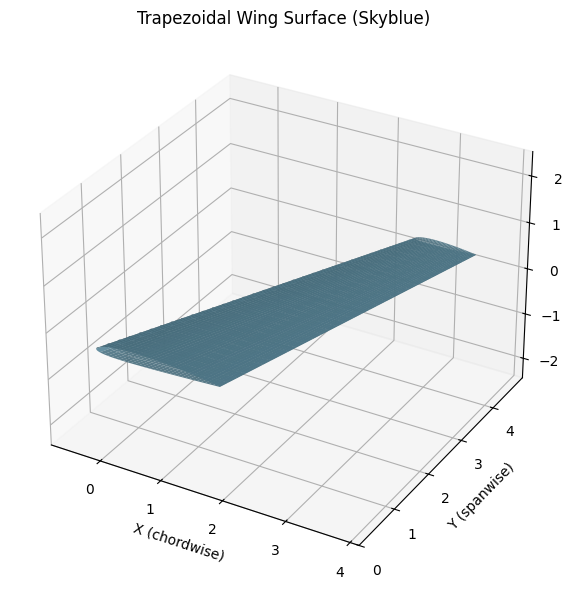

In [263]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def generate_trapezoidal_wing_surface(
    b=10.0, c_root=2.0, c_tip=1.0,
    sweep_LE=np.deg2rad(25),
    m=0.02, p_cam=0.4, t=0.12,
    N=128
):
    eta = np.linspace(0,1,N,endpoint=False)
    xi  = np.linspace(0,1,N,endpoint=False)
    XI, ETA = np.meshgrid(xi, eta, indexing='ij')

    # chord, camber, thickness
    C  = c_root*(1-ETA) + c_tip*ETA
    yc = np.where(
        XI<p_cam,
        m/(p_cam**2)*(2*p_cam*XI - XI**2),
        m/((1-p_cam)**2)*((1-2*p_cam)+2*p_cam*XI - XI**2)
    )
    yt = 5*t*(0.2969*np.sqrt(XI)
             -0.1260*XI
             -0.3516*XI**2
             +0.2843*XI**3
             -0.1015*XI**4)

    # coordinates
    x_le = 0.5 * b * ETA * np.tan(sweep_LE)
    X = x_le + XI*C
    Y = 0.5 * b * ETA
    Zup = (yc+yt)*C
    Zlo = (yc-yt)*C

    return X, Y, Zup, Zlo

# plot
X, Y, Zup, Zlo = generate_trapezoidal_wing_surface()
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Zup,  rstride=4, cstride=4, color='#87CEEB', edgecolor='none', alpha=0.9)
ax.plot_surface(X, Y, Zlo,  rstride=4, cstride=4, color='#87CEEB', edgecolor='none', alpha=0.9)

# equal aspect
max_range = np.array([X.max()-X.min(), Y.max()-Y.min(), Zup.max()-Zlo.min()]).max()/2
mid_x = (X.max()+X.min())/2
mid_y = (Y.max()+Y.min())/2
mid_z = (Zup.max()+Zlo.min())/2
ax.set_xlim(mid_x-max_range, mid_x+max_range)
ax.set_ylim(mid_y-max_range, mid_y+max_range)
ax.set_zlim(mid_z-max_range, mid_z+max_range)

ax.set_xlabel('X (chordwise)')
ax.set_ylabel('Y (spanwise)')
ax.set_zlabel('Z (thickness)')
ax.set_title('Trapezoidal Wing Surface (Skyblue)')
plt.tight_layout()
plt.show()


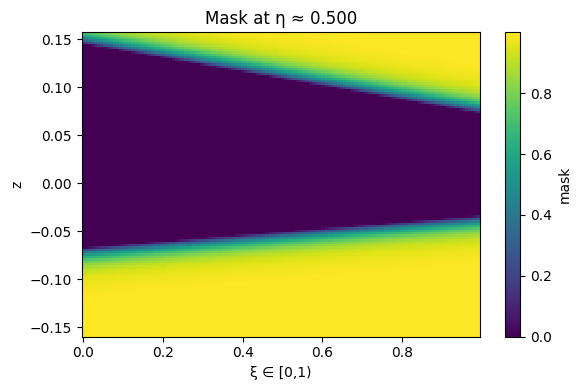

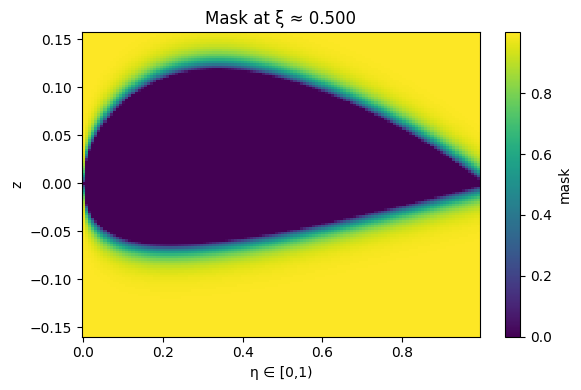

In [264]:
import numpy as np
import matplotlib.pyplot as plt

# ─── Wing surface function (from last version) ──────────────────────────────
def generate_trapezoidal_wing_surface(
    b=10.0, c_root=2.0, c_tip=1.0,
    sweep_LE=np.deg2rad(25),
    m=0.02, p_cam=0.4, t=0.12,
    N=128
):
    eta = np.linspace(0,1,N,endpoint=False)
    xi  = np.linspace(0,1,N,endpoint=False)
    XI, ETA = np.meshgrid(xi, eta, indexing='ij')

    # chord, camber, thickness
    C  = c_root*(1-ETA) + c_tip*ETA
    yc = np.where(
        XI < p_cam,
        m/(p_cam**2)*(2*p_cam*XI - XI**2),
        m/((1-p_cam)**2)*((1-2*p_cam)+2*p_cam*XI - XI**2)
    )
    yt = 5*t*(0.2969*np.sqrt(XI)
             -0.1260*XI
             -0.3516*XI**2
             +0.2843*XI**3
             -0.1015*XI**4)

    # coordinates with sweep
    x_le = 0.5 * b * ETA * np.tan(sweep_LE)
    X = x_le + XI*C
    Y = 0.5 * b * ETA
    Zup = (yc + yt)*C
    Zlo = (yc - yt)*C

    return eta, xi, X, Y, Zup, Zlo

# ─── 1) Generate wing surface ───────────────────────────────────────────────
eta, xi, Xw, Yw, Zup, Zlo = generate_trapezoidal_wing_surface()
N = Xw.shape[0]  # grid size

# ─── 2) Define z-grid based on wing thickness ───────────────────────────────
zlim = np.max(np.abs([Zup, Zlo]))
z_vals = np.linspace(-zlim, zlim, N, endpoint=False)

# ─── 3) Build 3D grid (η, ξ, z) ──────────────────────────────────────────────
ETA3, XI3, ZG = np.meshgrid(eta, xi, z_vals, indexing='ij')

# ─── 4) Broadcast wing surfaces to 3D ───────────────────────────────────────
Zup3d  = Zup[:, :, None]  # shape (N, N, 1)
Zlow3d = Zlo[:, :, None]

# ─── 5) Initialize mask = 1 everywhere ─────────────────────────────────────
mask = np.ones_like(ZG)

# 5a) Inside wing: z between lower and upper surfaces → mask = 0
inside = (ZG >= Zlow3d) & (ZG <= Zup3d)
mask[inside] = 0.0

# 5b) Above wing: mask = 1 - exp(-100 * (z - Zup))
zd_above = ZG - Zup3d
above = zd_above > 0
mask[above] = 1.0 - np.exp(-100.0 * zd_above[above])

# 5c) Below wing: mask = 1 - exp(-100 * (Zlow - z))
zd_below = Zlow3d - ZG
below = zd_below > 0
mask[below] = 1.0 - np.exp(-100.0 * zd_below[below])

# ─── 6) Visualize a central spanwise (η) slice ──────────────────────────────
i_mid = N//2
plt.figure(figsize=(6,4))
plt.pcolormesh(xi, z_vals, mask[i_mid,:,:].T, shading='auto', cmap='viridis')
plt.xlabel('ξ ∈ [0,1)')
plt.ylabel('z')
plt.title(f'Mask at η ≈ {eta[i_mid]:.3f}')
plt.colorbar(label='mask')
plt.tight_layout()
plt.show()

# ─── 7) Visualize a central chordwise (ξ) slice ─────────────────────────────
j_mid = N//2
plt.figure(figsize=(6,4))
plt.pcolormesh(eta, z_vals, mask[:,j_mid,:].T, shading='auto', cmap='viridis')
plt.xlabel('η ∈ [0,1)')
plt.ylabel('z')
plt.title(f'Mask at ξ ≈ {xi[j_mid]:.3f}')
plt.colorbar(label='mask')
plt.tight_layout()
plt.show()


C:\Users\siddhartha.morales\AppData\Local\Temp\ipykernel_20288\3135391486.py:70: RuntimeWarning: invalid value encountered in sqrt
  yt_g = 5*t*(0.2969*np.sqrt(xi_g)


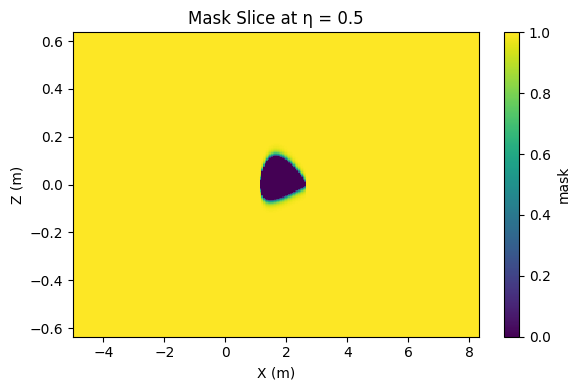

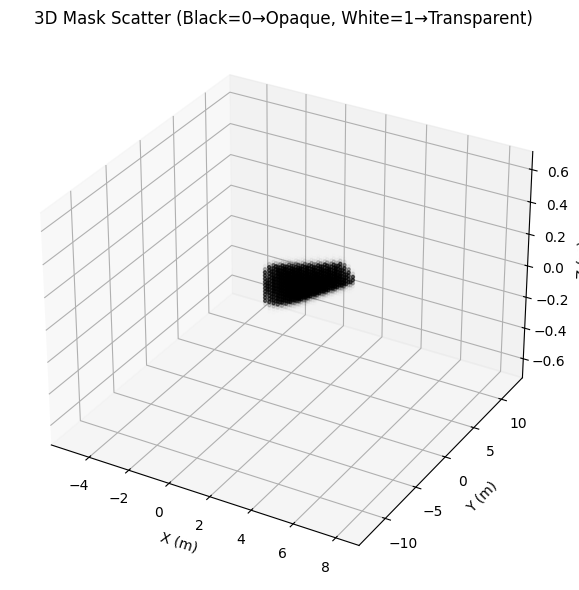

In [265]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ─── 1) Core wing surface function ───────────────────────────────────────────
def generate_trapezoidal_wing_surface(
    b=10.0, c_root=2.0, c_tip=1.0,
    sweep_LE=np.deg2rad(25),
    m=0.02, p_cam=0.4, t=0.12,
    N=128
):
    eta = np.linspace(0,1,N,endpoint=False)
    xi  = np.linspace(0,1,N,endpoint=False)
    XI, ETA = np.meshgrid(xi, eta, indexing='ij')

    C  = c_root*(1-ETA) + c_tip*ETA
    yc = np.where(XI<p_cam,
                  m/(p_cam**2)*(2*p_cam*XI - XI**2),
                  m/((1-p_cam)**2)*(1-2*p_cam + 2*p_cam*XI - XI**2))
    yt = 5*t*(0.2969*np.sqrt(XI)
             -0.1260*XI
             -0.3516*XI**2
             +0.2843*XI**3
             -0.1015*XI**4)

    x_le = 0.5 * b * ETA * np.tan(sweep_LE)
    Xw  = x_le + XI * C
    Yw  = 0.5 * b * ETA
    Zup = (yc + yt) * C
    Zlo = (yc - yt) * C

    return Xw, Yw, Zup, Zlo, b

# Generate wing surface
Xw, Yw, Zup, Zlo, b = generate_trapezoidal_wing_surface(N=128)

# ─── 2) Build mask in extended domain (2× larger) ───────────────────────────
# Wing bounding box
xmin, xmax = Xw.min(), Xw.max()
ymin, ymax = Yw.min(), Yw.max()
zlim = np.max(np.abs([Zup, Zlo]))

# Extended domain twice as large around center
mid_x = 0.5*(xmin + xmax)
mid_y = 0.5*(ymin + ymax)
half_dx = (xmax - xmin)
half_dy = (ymax - ymin)

N_dom = 2**8
X_vals = np.linspace(mid_x - 2*half_dx, mid_x + 2*half_dx, N_dom)
Y_vals = np.linspace(mid_y - 3*half_dy, mid_y + 2*half_dy, N_dom)
Z_vals = np.linspace(-4*zlim, 4*zlim, N_dom)

Xg, Yg, Zg = np.meshgrid(X_vals, Y_vals, Z_vals, indexing='ij')

# Map to (eta, xi)
eta_g = Yg / (0.5*b)
x_le_g = 0.5 * b * eta_g * np.tan(np.deg2rad(25))
C_g = (2.0*(1-eta_g) + 1.0*eta_g)  # chord
xi_g = (Xg - x_le_g) / C_g

# Core region
core = (eta_g>=0)&(eta_g<1)&(xi_g>=0)&(xi_g<1)

# Surfaces
m, p_cam, t = 0.02, 0.4, 0.12
yc_g = np.where(xi_g<p_cam,
                m/(p_cam**2)*(2*p_cam*xi_g - xi_g**2),
                m/((1-p_cam)**2)*(1-2*p_cam + 2*p_cam*xi_g - xi_g**2))
yt_g = 5*t*(0.2969*np.sqrt(xi_g)
           -0.1260*xi_g
           -0.3516*xi_g**2
           +0.2843*xi_g**3
           -0.1015*xi_g**4)
Zup_g  = (yc_g + yt_g) * C_g
Zlo_g  = (yc_g - yt_g) * C_g

# Build mask
mask = np.ones_like(Zg)
inside = core & (Zg >= Zlo_g) & (Zg <= Zup_g)
mask[inside] = 0.0
above = core & (Zg > Zup_g)
mask[above] = 1.0 - np.exp(-100*(Zg[above] - Zup_g[above]))
below = core & (Zg < Zlo_g)
mask[below] = 1.0 - np.exp(-100*(Zlo_g[below] - Zg[below]))

# ─── 3) Chordwise eta=0.5 slice with physical X axis ────────────────────────
eta_slice = 0.5
y_slice = 0.5 * b * eta_slice
j_y = np.argmin(np.abs(Y_vals - y_slice))
X_line = X_vals
mask_eta_slice = mask[:, j_y, :]

plt.figure(figsize=(6,4))
plt.pcolormesh(X_line, Z_vals, mask_eta_slice.T, shading='auto', cmap='viridis')
plt.xlabel('X (m)')
plt.ylabel('Z (m)')
plt.title('Mask Slice at η = 0.5')
plt.colorbar(label='mask')
plt.tight_layout()
plt.show()

# ─── 4) 3D scatter of mask values ────────────────────────────────────────────
# Downsample for plotting
step = 4
X_s = Xg[::step,::step,::step].flatten()
Y_s = Yg[::step,::step,::step].flatten()
Z_s = Zg[::step,::step,::step].flatten()
m_s = mask[::step,::step,::step].flatten()

# RGBA colors: black for mask=0, transparent for mask=1
colors = np.zeros((m_s.size, 4))
colors[:, 3] = 1.0 - m_s  # alpha channel

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_s, Y_s, Z_s, color=colors, s=5)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title('3D Mask Scatter (Black=0→Opaque, White=1→Transparent)')
plt.tight_layout()
plt.show()


In [266]:
p=8
no = tntt.TT(mask, [2,2,2]*8, eps=1e-3)
np.max(no.R)

119

In [267]:
zo = tntt.TT(zM3(tn.tensor(mask,dtype=tn.float64),p), [2,2,2]*8, eps=1e-3)
np.max(zo.R)

120

In [268]:
tnmask = tn.tensor(mask,dtype=tn.float64).permute((1, 0, 2))  # ensure shape is (N, N, N)
tz = tn.zeros_like(tnmask)
x_order = bit_reverse_indices(p)
for i in range(2**p):
    tz[i,:,:] = zM(tnmask[i,:,:],p)
tz = tz[x_order,:,:]
ttmask = tntt.TT(tz,[2]*p+[2,2]*p,eps=1e-3)
print(np.max(ttmask.R))


201


In [272]:

# assumes `mask` is a NumPy array
X_np = mask.astype(np.float64)              # keep high precision if you want
#X_np = np.transpose(X_np, axes=[0, 1, 2])   # your original transpose (no-op if already)
X = tn.from_numpy(X_np).to(dtype=tn.float64)

# ── HOSVD / Tucker via SVD on unfoldings ─────────────────────────────────────
def unfold_tn(X, mode):
    # move the chosen mode to the front, then flatten the rest
    return tn.movedim(X, mode, 0).reshape(X.shape[mode], -1)

def tucker_hosvd(X, ranks):
    """
    X: (I, J, K) torch tensor
    ranks: (r1, r2, r3)
    returns: core G (r1, r2, r3), factors (U1, U2, U3) with shapes (I,r1),(J,r2),(K,r3)
    """
    I, J, K = X.shape
    r1 = min(ranks[0], I)
    r2 = min(ranks[1], J)
    r3 = min(ranks[2], K)

    U = []
    for mode, r in enumerate((r1, r2, r3)):
        M = unfold_tn(X, mode)                               # (dim_mode, prod_other_dims)
        # SVD in torch
        U_mode, S_mode, Vh_mode = tn.linalg.svd(M, full_matrices=False)
        U.append(U_mode[:, :r].contiguous())                 # (dim_mode, r)

    U1, U2, U3 = U

    # Core: G = X ×1 U1^T ×2 U2^T ×3 U3^T  (einsum form)
    # X: ijk, U1^T: ai, U2^T: bj, U3^T: ck -> abc
    G = tn.einsum('ijk,ai,bj,ck->abc', X, U1.T, U2.T, U3.T)

    return G, (U1, U2, U3)

def tucker_reconstruct(G, factors):
    U1, U2, U3 = factors
    # X_hat = G ×1 U1 ×2 U2 ×3 U3  (einsum form)
    # G: abc, U1: ia, U2: jb, U3: kc -> ijk
    X_hat = tn.einsum('abc,ia,jb,kc->ijk', G, U1, U2, U3)
    return X_hat

# ── Run HOSVD/Tucker ─────────────────────────────────────────────────────────
rt = 100
G, U = tucker_hosvd(X, ranks=(rt, rt, rt))
X_hat = tucker_reconstruct(G, U)

# ── Errors ───────────────────────────────────────────────────────────────────
err_abs = tn.linalg.norm((X - X_hat).reshape(-1)).item()
err_rel = err_abs / tn.linalg.norm(X.reshape(-1)).item()

print(f"Core shape: {tuple(G.shape)}")
print(f"Abs L2 error: {err_abs:.6e}")
print(f"Rel error   : {err_rel:.6e}")


Core shape: (100, 100, 100)
Abs L2 error: 1.369542e-11
Rel error   : 3.348294e-15


In [273]:
comb_qtt = combqtt(G,U,eps=1e-10)
comb_c = tree_compress(comb_qtt,eps=1e-3)
comp_combqtt = comb_comp(comb_qtt)
comp_combc = comb_comp(comb_c)
mrank_cqtt = comb_max_rank(comb_qtt)
mrank_cqtt_c = comb_max_rank(comb_c)
print(comp_combqtt)
print(comp_combc)
print(mrank_cqtt)
#np.linalg.norm(G - tntt.TT(root).full())

0.027173757553100586
0.00713270902633667
128


In [276]:
cr = combqtt_full(comb_c)
err_abs = tn.linalg.norm((X - cr).reshape(-1)).item()
err_rel = err_abs / tn.linalg.norm(X.reshape(-1)).item()

print(f"Abs L2 error: {err_abs:.6e}")
print(f"Rel error   : {err_rel:.6e}")

Abs L2 error: 5.131651e+00
Rel error   : 1.254600e-03


In [275]:
print("\033[91m" + 
    str(np.max(zo.R)) + ", " + str(int(erank(zo.R, zo.N))) + ", " + str(tt_comp(zo)) +
    "\033[0m")

print("\033[92m" + 
    str(np.max(ttmask.R)) + ", " + str(int(erank(ttmask.R, ttmask.N))) + ", " + str(tt_comp(ttmask)) +
    "\033[0m")

print("\033[94m" + 
    str(comb_max_rank(comb_c)) + ",  , "+str(comb_comp(comb_c))  + 
    "\033[0m")

120, 47, 0.005820035934448242
201, 99, 0.026072263717651367
59,  , 0.00713270902633667


## Model 4

[check] TE_x - LE_x at mid-span = 4.0478 (>0 means TE toward +X)


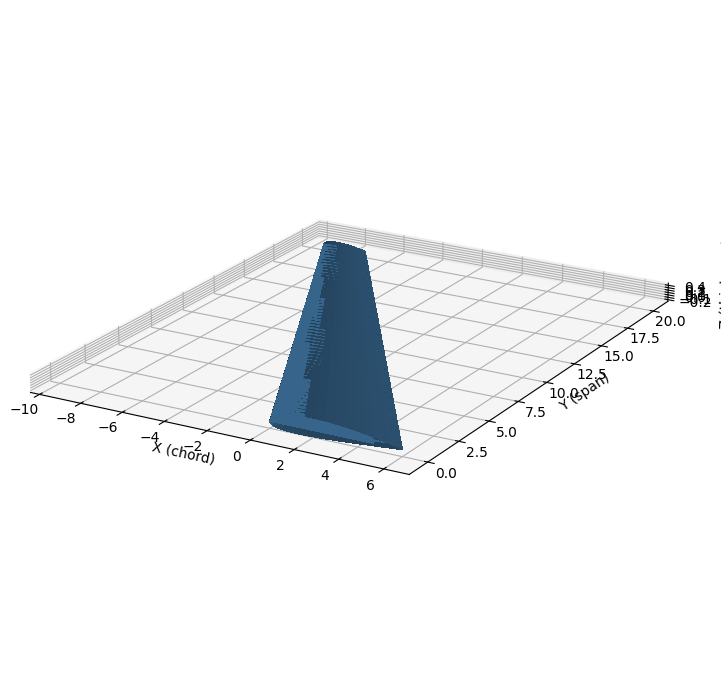

[shapes] chi_grid: (120, 60, 120)  mask01: (120, 60, 120)


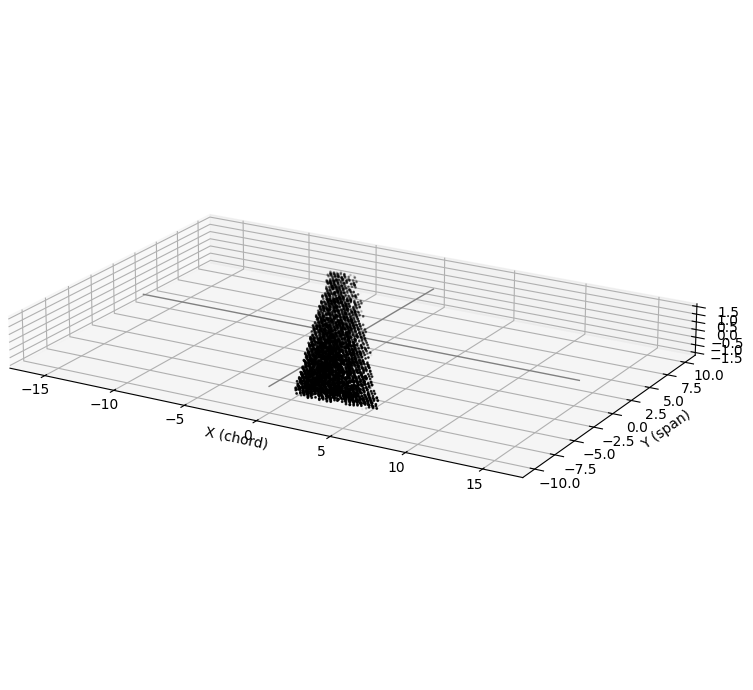

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import trimesh
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# =========================
# 1) Airfoil + pure wing (with explicit chord & sweep signs)
# =========================
def naca4_closed_loop(n=120, m=0.02, p=0.4, t=0.12):
    assert n % 2 == 0 and n >= 6
    n2  = n // 2
    beta = np.linspace(0.0, np.pi, n2 + 1)
    x  = 0.5 * (1.0 - np.cos(beta))            # [0,1]
    x_ = np.clip(x, 0.0, 1.0)

    yt = 5*t*(0.2969*np.sqrt(x_) - 0.1260*x - 0.3516*x**2
              + 0.2843*x**3 - 0.1015*x**4)
    yc = np.where(x < p, m/p**2*(2*p*x - x**2),
                        m/(1-p)**2*((1 - 2*p) + 2*p*x - x**2))
    dy = np.where(x < p, 2*m/p**2*(p - x),
                        2*m/(1-p)**2*(p - x))
    th = np.arctan(dy)

    xu = x - yt*np.sin(th); zu = yc + yt*np.cos(th)
    xl = x + yt*np.sin(th); zl = yc - yt*np.cos(th)

    upper_x = xu[::-1]            # LE->TE
    upper_z = zu[::-1]
    lower_x = xl[1:-1][::-1]      # TE->LE (drop duplicates)
    lower_z = zl[1:-1][::-1]
    return np.concatenate([upper_x, lower_x]), np.concatenate([upper_z, lower_z])

def build_wing(
    half_span=20.0, c_root=6.0, taper=0.36,
    sweep_LE_deg=25.0, dihedral_deg=0.0,
    n_chord=120, n_wing=60,
    chord_forward=True, backward_sweep=True,
):
    # section
    x_sec, z_sec = naca4_closed_loop(n=n_chord, m=0.02, p=0.4, t=0.12)

    c_tip = taper * c_root
    c_sign = +1.0 if chord_forward else -1.0          # LE -> TE along +X or -X
    sw_sign = -1.0 if backward_sweep else +1.0        # LE shift with span

    sweep_off = np.tan(np.deg2rad(sweep_LE_deg)) * half_span * sw_sign
    dihedral  = np.tan(np.deg2rad(dihedral_deg))

    X = np.zeros((n_wing, n_chord))
    Y = np.zeros((n_wing, n_chord))
    Z = np.zeros((n_wing, n_chord))

    for j in range(n_wing):
        s = j / (n_wing - 1.0)              # 0..1
        c = c_root + (c_tip - c_root) * s
        x_le = sweep_off * s                # note: if backward_sweep=True, this is negative
        y    = half_span * s
        z0   = dihedral * y

        X[j, :] = x_le + c_sign * c * x_sec
        Y[j, :] = y
        Z[j, :] = z0   + c * z_sec

    return X, Y, Z

# Choose the conventions you want here:
X, Y, Z = build_wing(
    chord_forward=True,   # LE->TE in +X (typical)
    backward_sweep=True   # airliner-style backward sweep
)

# Direction sanity check (mid-span)
mid = X.shape[0] // 2
LE_x = X[mid, :].min()
TE_x = X[mid, :].max()
print(f"[check] TE_x - LE_x at mid-span = {TE_x - LE_x:.4f} (>0 means TE toward +X)")

# =========================
# 2) Plot parametric wing (with axes + arrow)
# =========================
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, rstride=1, cstride=3, color='steelblue',
                edgecolor='none', antialiased=False)
# arrow at mid-span showing chord direction
y0 = Y[mid, 0]
z0 = np.mean(Z[mid, :])
ax.quiver(LE_x, y0, z0, (TE_x-LE_x)*0.15, 0, 0, color='gray',
          linewidth=2, arrow_length_ratio=0.15)

ax.view_init(elev=20, azim=-60)
ax.set_xlabel('X (chord)'); ax.set_ylabel('Y (span)'); ax.set_zlabel('Z (thickness)')
ax.set_box_aspect([float(np.ptp(X)), float(np.ptp(Y)), float(np.ptp(Z))])
plt.tight_layout(); plt.show()

# =========================
# 3) Center wing; define 4x box in X,Z (Y unchanged)
# =========================
x_mid = 0.5*(X.min()+X.max())
y_mid = 0.5*(Y.min()+Y.max())
z_mid = 0.5*(Z.min()+Z.max())
Xc, Yc, Zc = X-x_mid, Y-y_mid, Z-z_mid

X_extent = float(Xc.max() - Xc.min())
Y_extent = float(Yc.max() - Yc.min())      # unchanged
Z_extent = float(Zc.max() - Zc.min())

gx_min, gx_max = -X_extent,  X_extent
gy_min, gy_max =  Yc.min(),      Yc.max()
gz_min, gz_max = -2.0*Z_extent,  2.0*Z_extent

dz_max = max(Z_extent, 1e-9)               # normalization for decay

# =========================
# 4) Mesh + ray helpers (lightweight)
# =========================
def triangulate_swept_cyclic(Xs, Ys, Zs):
    rows, cols = Xs.shape
    V = np.column_stack([Xs.ravel(), Ys.ravel(), Zs.ravel()])
    faces = []
    for i in range(rows - 1):
        b0 = i*cols; b1 = (i+1)*cols
        for j in range(cols):
            jn = (j+1) % cols
            a = b0+j; b = b0+jn; c = b1+j; d = b1+jn
            faces.append([a,c,b]); faces.append([b,c,d])
    loop0 = np.arange(0, cols)
    cent0 = V[loop0].mean(axis=0); idx0 = V.shape[0]
    V = np.vstack([V, cent0])
    for j in range(cols): faces.append([loop0[j], loop0[(j+1)%cols], idx0])
    loop1 = np.arange((rows-1)*cols, rows*cols)
    cent1 = V[loop1].mean(axis=0); idx1 = V.shape[0]
    V = np.vstack([V, cent1])
    for j in range(cols): faces.append([loop1[(j+1)%cols], loop1[j], idx1])
    return trimesh.Trimesh(vertices=V, faces=np.asarray(faces, np.int64), process=True)

wing_mesh = triangulate_swept_cyclic(Xc, Yc, Zc)

try:
    from trimesh.ray.ray_pyembree import RayMeshIntersector
    RAY = "embree"
except Exception:
    from trimesh.ray.ray_triangle import RayMeshIntersector
    RAY = "python"
wing_ray = RayMeshIntersector(wing_mesh)

def contains_chunked(intersector, pts, chunk=200_000):
    pts = np.asarray(pts, float)
    out = np.empty(pts.shape[0], dtype=bool)
    for i in range(0, pts.shape[0], chunk):
        sl = slice(i, min(i+chunk, pts.shape[0]))
        out[sl] = intersector.contains_points(pts[sl])
    return out

def dz_along_z_light(intersector, pts, chunk=150_000):
    """
    Distance along +/-Z using rays; if both miss, fallback to AABB distance in Z.
    """
    pts = np.asarray(pts, float)
    out = np.empty(pts.shape[0], float)
    mn, mx = intersector.mesh.bounds
    dir_p = np.array([0.0, 0.0,  1.0])
    dir_n = np.array([0.0, 0.0, -1.0])
    for i in range(0, pts.shape[0], chunk):
        sl = slice(i, min(i+chunk, pts.shape[0]))
        P = pts[sl]
        loc_p, ind_p, _ = intersector.intersects_location(P, np.repeat(dir_p[None,:], P.shape[0], axis=0), multiple_hits=False)
        loc_n, ind_n, _ = intersector.intersects_location(P, np.repeat(dir_n[None,:], P.shape[0], axis=0), multiple_hits=False)
        d = np.full(P.shape[0], np.inf, float)
        if ind_p.size: d[ind_p] = np.minimum(d[ind_p], np.abs(loc_p[:,2] - P[ind_p,2]))
        if ind_n.size: d[ind_n] = np.minimum(d[ind_n], np.abs(loc_n[:,2] - P[ind_n,2]))
        miss = ~np.isfinite(d)
        if np.any(miss):
            zmin, zmax = mn[2], mx[2]
            z = P[miss, 2]
            dz = np.where(z < zmin, zmin - z,
                 np.where(z > zmax, z - zmax, np.minimum(z - zmin, zmax - z)))
            d[miss] = np.abs(dz)
        out[sl] = d
    return out

# =========================
# 5) Grid & SHARP decaying mask (k=1000) + 3D ARRAY OUTPUT
# =========================
# Grid in box: X,Z expanded 4×; Y unchanged
nx, ny, nz = 120, 60, 120   # denser in X,Z
gx = np.linspace(gx_min, gx_max, nx)
gy = np.linspace(gy_min, gy_max, ny)
gz = np.linspace(gz_min, gz_max, nz)
Gx, Gy, Gz = np.meshgrid(gx, gy, gz, indexing='ij')  # ij -> (x,y,z) order

# Flatten for queries
grid_pts = np.stack([Gx, Gy, Gz], axis=-1).reshape(-1, 3)

# Prefilter near AABB to save time
pad_xz = 0.1 * max(X_extent, Z_extent)
mn, mx = wing_mesh.bounds
mn = mn + np.array([-pad_xz, 0.0, -pad_xz])
mx = mx + np.array([ pad_xz, 0.0,  pad_xz])
near = (grid_pts[:,0] >= mn[0]) & (grid_pts[:,0] <= mx[0]) & \
       (grid_pts[:,1] >= mn[1]) & (grid_pts[:,1] <= mx[1]) & \
       (grid_pts[:,2] >= mn[2]) & (grid_pts[:,2] <= mx[2])

# Initialize to 1 (outside)
val_flat = np.ones(grid_pts.shape[0], float)
k_sharp = 1000.0

if np.any(near):
    P = grid_pts[near]
    inside = contains_chunked(wing_ray, P)
    val_n = np.ones(P.shape[0], float)
    val_n[inside] = 0.0
    if np.any(~inside):
        dz = dz_along_z_light(wing_ray, P[~inside])
        val_n[~inside] = 1.0 - np.exp(-k_sharp * dz / dz_max)
    val_flat[near] = val_n

# >>> This is your 3D mask array in the embedded space:
chi_grid = val_flat.reshape(nx, ny, nz)     # 0 inside, sharp-decayed outside

# Optional hard 0/1 mask:
mask01 = (chi_grid > 0).astype(np.uint8)

print(f"[shapes] chi_grid: {chi_grid.shape}  mask01: {mask01.shape}")

# =========================
# 6) Quick visualization (scatter with axes)
# =========================
# Build per-point alpha from chi_grid for a sample slice of points (to keep light)
alpha = 1.0 - np.clip(chi_grid.ravel(), 0.0, 1.0)
colors = np.column_stack([np.zeros_like(alpha),
                          np.zeros_like(alpha),
                          np.zeros_like(alpha),
                          alpha])

# Subsample for speed if needed
max_points = 250_000
N = grid_pts.shape[0]
if N > max_points:
    idx = np.random.choice(N, max_points, replace=False)
    Pshow, Cshow = grid_pts[idx], colors[idx]
else:
    Pshow, Cshow = grid_pts, colors

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(Pshow[:,0], Pshow[:,1], Pshow[:,2], s=1, c=Cshow, marker='o')

# axes
axis_col = (0.5, 0.5, 0.5)
ax.plot([gx_min, gx_max], [0,0], [0,0], lw=1, color=axis_col)
ax.plot([0,0], [gy_min, gy_max], [0,0], lw=1, color=axis_col)
ax.plot([0,0], [0,0], [gz_min, gz_max], lw=1, color=axis_col)

ax.set_xlabel('X (chord)')
ax.set_ylabel('Y (span)')
ax.set_zlabel('Z (thickness)')
ax.set_box_aspect([float(np.ptp(Pshow[:,0])),
                   float(np.ptp(Pshow[:,1])),
                   float(np.ptp(Pshow[:,2]))])
ax.view_init(elev=20, azim=-60)
plt.tight_layout(); plt.show()


In [49]:
2**21

2097152

# Wing + winglet

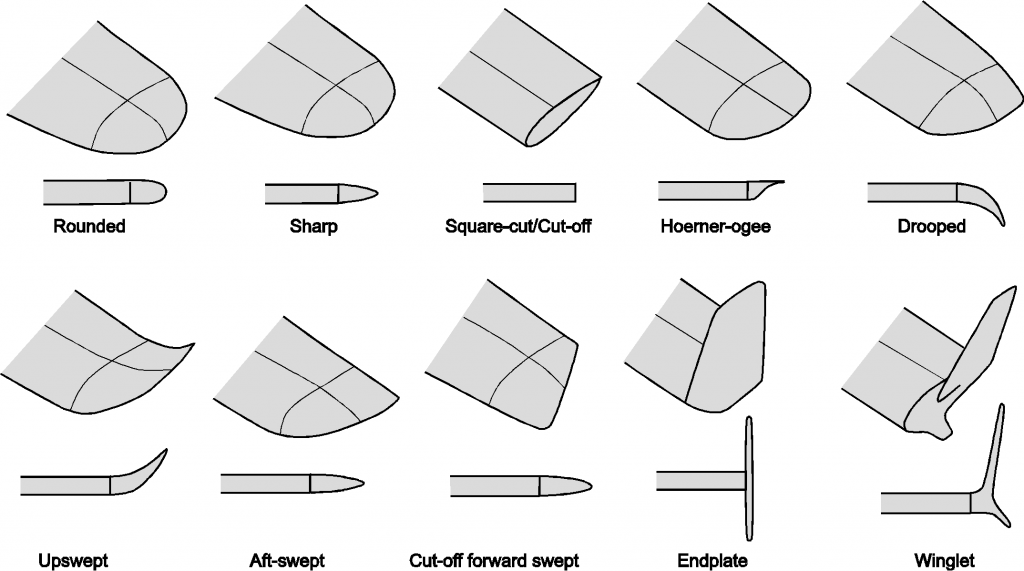

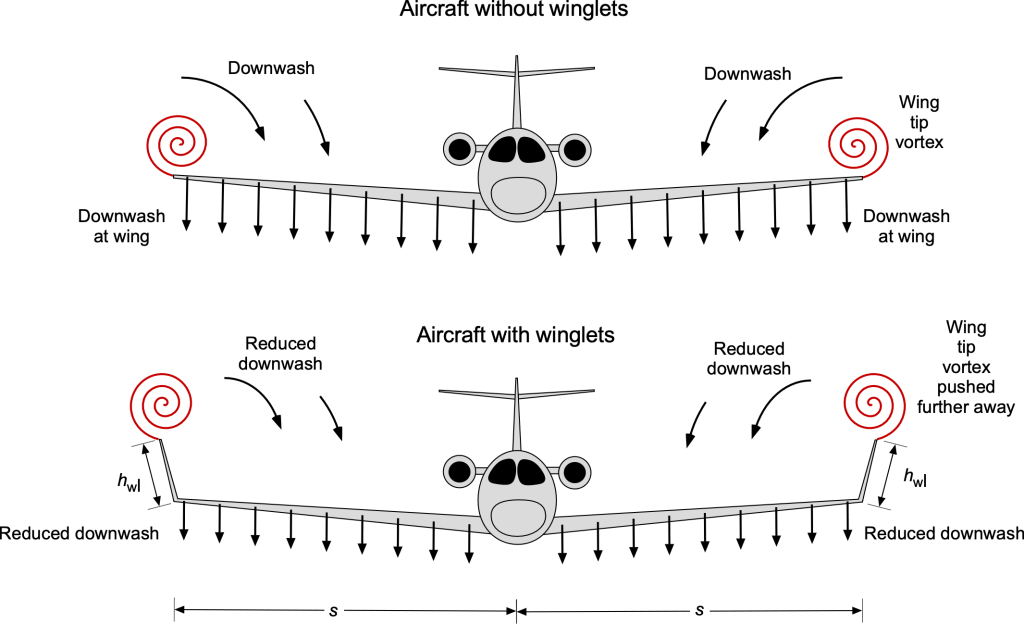

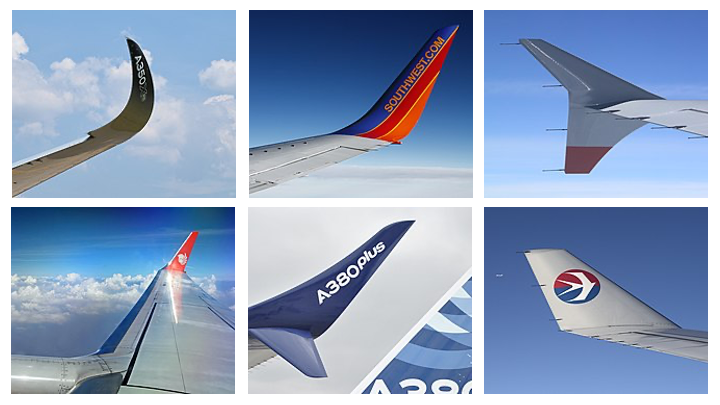

In [361]:
%matplotlib ipympl

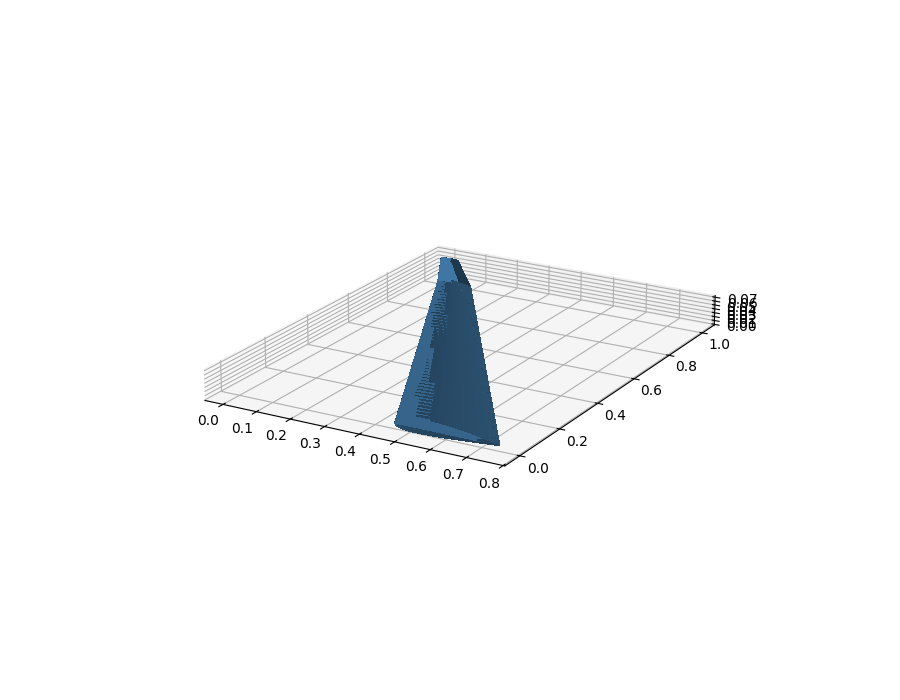

In [362]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -----------------------------
# Airfoil: NACA 4-digit (closed)
# -----------------------------
def naca4_closed_loop(n=120, m=0.02, p=0.4, t=0.12):
    """
    CLOSED airfoil loop (x,z) with EXACTLY n points (n even).
    Ordering: upper LE->TE, then lower TE->LE (no duplicate LE/TE).
    """
    assert n % 2 == 0 and n >= 6
    n_half = n // 2
    beta = np.linspace(0.0, np.pi, n_half + 1)
    x = 0.5 * (1.0 - np.cos(beta))       # [0,1]
    x_safe = np.clip(x, 0.0, 1.0)

    # NACA thickness & camber
    yt = 5*0.12*(0.2969*np.sqrt(x_safe) - 0.1260*x - 0.3516*x**2
                 + 0.2843*x**3 - 0.1015*x**4)
    yc = np.where(x < p, m/p**2*(2*p*x - x**2),
                        m/(1-p)**2*((1 - 2*p) + 2*p*x - x**2))
    dyc = np.where(x < p, 2*m/p**2*(p - x),
                        2*m/(1-p)**2*(p - x))
    th = np.arctan(dyc)

    xu = x - yt*np.sin(th); zu = yc + yt*np.cos(th)
    xl = x + yt*np.sin(th); zl = yc - yt*np.cos(th)

    upper_x = xu[::-1]               # LE -> TE
    upper_z = zu[::-1]
    lower_x = xl[1:-1][::-1]         # TE -> LE (drop TE & LE)
    lower_z = zl[1:-1][::-1]

    x_loop = np.concatenate([upper_x, lower_x])  # n points
    z_loop = np.concatenate([upper_z, lower_z])
    return x_loop, z_loop

def smoothstep(t):  # smooth rotation blend
    return t*t*(3.0 - 2.0*t)

# -----------------------------
# More realistic proportions
# -----------------------------
half_span      = 20.0                 # arbitrary units (we'll normalize later)
taper_ratio    = 0.36                 # tip/root chord ratio (typical 0.3–0.45)
c_root         = 6.0
c_tip          = taper_ratio * c_root
sweep_LE_deg   = 25.0                 # 20–35° typical
dihedral_deg   = 0.0                  # keep 0 for clarity in this view

# Winglet as fraction of half-span (≈ 4–8%)
winglet_h_frac = 0.06                 # 6% of half-span
wl_height      = winglet_h_frac * half_span
wl_cant_out    = 0.02 * half_span     # small outward cant (~2% span)
wl_alpha_max   = 65.0                 # degrees rotation toward vertical
wl_top_chord   = 0.5 * c_tip          # slimmer chord at winglet tip

# Discretization (kept modest for speed)
n_chord = 120   # even
n_wing  = 50
n_wl    = 30

# -----------------------------
# Build continuous surface
# -----------------------------
x_sec, z_sec = naca4_closed_loop(n=n_chord, m=0.02, p=0.4, t=0.12)
sweep_off = np.tan(np.deg2rad(sweep_LE_deg)) * half_span
dihedral  = np.tan(np.deg2rad(dihedral_deg))

n_stations = n_wing + n_wl
X = np.zeros((n_stations, n_chord))
Y = np.zeros((n_stations, n_chord))
Z = np.zeros((n_stations, n_chord))

# Wing stations
for j in range(n_wing):
    s = j / (n_wing - 1)              # 0..1
    c = c_root + (c_tip - c_root) * s
    x_le = -sweep_off * s
    y    = half_span * s
    z0   = dihedral * y

    X[j, :] = x_le + c * x_sec
    Y[j, :] = y
    Z[j, :] = z0   + c * z_sec

# Winglet stations (continuous blend)
for k in range(1, n_wl + 1):
    t = k / n_wl
    c = c_tip + (wl_top_chord - c_tip) * t
    x_le = -sweep_off

    alpha = np.deg2rad(wl_alpha_max) * smoothstep(t)
    ca, sa = np.cos(alpha), np.sin(alpha)

    y_base = half_span + wl_cant_out * t
    z_base = wl_height * t

    x_local = x_le + c * x_sec
    z_local = c * z_sec

    y_rot = -z_local * sa
    z_rot =  z_local * ca

    X[n_wing - 1 + k, :] = x_local
    Y[n_wing - 1 + k, :] = y_base + y_rot
    Z[n_wing - 1 + k, :] = z_base + z_rot

# -----------------------------
# Uniformly normalize to unit cube [0,1]^3 (no distortion)
# -----------------------------
xmin, ymin, zmin = X.min(), Y.min(), Z.min()
xmax, ymax, zmax = X.max(), Y.max(), Z.max()
dx, dy, dz = xmax - xmin, ymax - ymin, zmax - zmin
scale = max(dx, dy, dz) if max(dx, dy, dz) > 0 else 1.0  # uniform scale
Xn = (X - xmin) / scale
Yn = (Y - ymin) / scale
Zn = (Z - zmin) / scale  # now the whole surface fits inside [0,1]^3

# -----------------------------
# Plot (parametric surface)
# -----------------------------
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Xn, Yn, Zn, rstride=1, cstride=3,
                color='steelblue', edgecolor='none', antialiased=False)

ax.view_init(elev=20, azim=-60)

# Aspect based on normalized extents
x_extent = float(np.ptp(Xn)); y_extent = float(np.ptp(Yn)); z_extent = float(np.ptp(Zn))
x_extent = max(x_extent, 1e-6); y_extent = max(y_extent, 1e-6); z_extent = max(z_extent, 1e-6)
ax.set_box_aspect([x_extent, y_extent, z_extent])



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import trimesh
import time
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# -----------------------------
# Airfoil: NACA 4-digit (closed)
# -----------------------------
def naca4_closed_loop(n=120, m=0.02, p=0.4, t=0.12):
    """
    CLOSED airfoil loop (x,z) with EXACTLY n points (n even).
    Ordering: upper LE->TE, then lower TE->LE (no duplicate LE/TE).
    """
    assert n % 2 == 0 and n >= 6
    n_half = n // 2
    beta = np.linspace(0.0, np.pi, n_half + 1)
    x = 0.5 * (1.0 - np.cos(beta))       # [0,1]
    x_safe = np.clip(x, 0.0, 1.0)

    # NACA thickness & camber
    yt = 5*t*(0.2969*np.sqrt(x_safe) - 0.1260*x - 0.3516*x**2
              + 0.2843*x**3 - 0.1015*x**4)
    yc = np.where(x < p, m/p**2*(2*p*x - x**2),
                        m/(1-p)**2*((1 - 2*p) + 2*p*x - x**2))
    dyc = np.where(x < p, 2*m/p**2*(p - x),
                        2*m/(1-p)**2*(p - x))
    th = np.arctan(dyc)

    xu = x - yt*np.sin(th); zu = yc + yt*np.cos(th)
    xl = x + yt*np.sin(th); zl = yc - yt*np.cos(th)

    # Closed loop: upper LE->TE, then lower TE->LE, drop duplicates
    upper_x = xu[::-1]               # length n_half+1
    upper_z = zu[::-1]
    lower_x = xl[1:-1][::-1]         # length n_half-1
    lower_z = zl[1:-1][::-1]

    x_loop = np.concatenate([upper_x, lower_x])  # n points
    z_loop = np.concatenate([upper_z, lower_z])
    return x_loop, z_loop

def smoothstep(t):
    return t*t*(3.0 - 2.0*t)

# -----------------------------
# Realistic-ish proportions
# -----------------------------
half_span      = 20.0
taper_ratio    = 0.36
c_root         = 6.0
c_tip          = taper_ratio * c_root
sweep_LE_deg   = 25.0
dihedral_deg   = 0.0

# Winglet ≈ 6% half-span
winglet_h_frac = 0.06
wl_height      = winglet_h_frac * half_span
wl_cant_out    = 0.02 * half_span
wl_alpha_max   = 65.0
wl_top_chord   = 0.5 * c_tip


p = 6
n_p = 2**p
# Discretization (moderate for speed)
n_chord = n_p   # even
n_wing  = n_p
n_wl    = n_p

# -----------------------------
# Build continuous surface
# -----------------------------
x_sec, z_sec = naca4_closed_loop(n=n_chord, m=0.02, p=0.4, t=0.12)
sweep_off = np.tan(np.deg2rad(sweep_LE_deg)) * half_span
dihedral  = np.tan(np.deg2rad(dihedral_deg))

n_stations = n_wing + n_wl
X = np.zeros((n_stations, n_chord))
Y = np.zeros((n_stations, n_chord))
Z = np.zeros((n_stations, n_chord))

# Wing stations
for j in range(n_wing):
    s = j / (n_wing - 1)
    c = c_root + (c_tip - c_root) * s
    x_le = -sweep_off * s
    y    = half_span * s
    z0   = dihedral * y

    X[j, :] = x_le + c * x_sec
    Y[j, :] = y
    Z[j, :] = z0   + c * z_sec

# Winglet stations (continuous blend)
for k in range(1, n_wl + 1):
    t = k / n_wl
    c = c_tip + (wl_top_chord - c_tip) * t
    x_le = -sweep_off

    alpha = np.deg2rad(wl_alpha_max) * smoothstep(t)
    ca, sa = np.cos(alpha), np.sin(alpha)

    y_base = half_span + wl_cant_out * t
    z_base = wl_height * t

    x_local = x_le + c * x_sec
    z_local = c * z_sec

    y_rot = -z_local * sa
    z_rot =  z_local * ca

    X[n_wing - 1 + k, :] = x_local
    Y[n_wing - 1 + k, :] = y_base + y_rot
    Z[n_wing - 1 + k, :] = z_base + z_rot

# -----------------------------
# Normalize to unit cube [0,1]^3, then center to [-0.5,0.5]^3
# (kept identical to your example)
# -----------------------------
xmin, ymin, zmin = X.min(), Y.min(), Z.min()
xmax, ymax, zmax = X.max(), Y.max(), Z.max()
dx, dy, dz = xmax - xmin, ymax - ymin, zmax - zmin
scale = max(dx, dy, dz) if max(dx, dy, dz) > 0 else 1.0
Xn = (X - xmin) / scale
Yn = (Y - ymin) / scale
Zn = (Z - zmin) / scale

# Centered wing coords in [-0.5, 0.5]^3
Xc = Xn - 0.5
Yc = Yn - 0.5
Zc = Zn - 0.5

# -----------------------------
# Build watertight mesh (for inside test)
# -----------------------------
def triangulate_swept_cyclic(X, Y, Z):
    rows, cols = X.shape
    V = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
    faces = []

    # side surface with cyclic chord wrap
    for i in range(rows - 1):
        base0 = i * cols
        base1 = (i + 1) * cols
        for j in range(cols):
            jn = (j + 1) % cols
            a = base0 + j
            b = base0 + jn
            c = base1 + j
            d = base1 + jn
            faces.append([a, c, b])
            faces.append([b, c, d])

    # cap at root (station 0)
    loop0 = np.arange(0, cols)
    centroid0 = V[loop0].mean(axis=0)
    idx_cent0 = V.shape[0]
    V = np.vstack([V, centroid0])
    for j in range(cols):
        a = loop0[j]
        b = loop0[(j + 1) % cols]
        c = idx_cent0
        faces.append([a, b, c])

    # cap at top (last station), reverse winding
    loop1 = np.arange((rows - 1) * cols, rows * cols)
    centroid1 = V[loop1].mean(axis=0)
    idx_cent1 = V.shape[0]
    V = np.vstack([V, centroid1])
    for j in range(cols):
        a = loop1[j]
        b = loop1[(j + 1) % cols]
        c = idx_cent1
        faces.append([b, a, c])

    F = np.asarray(faces, dtype=np.int64)
    return trimesh.Trimesh(vertices=V, faces=F, process=True)

mesh = triangulate_swept_cyclic(Xc, Yc, Zc)

# -----------------------------
# Fast contains: Embree if available + chunking
# -----------------------------
try:
    from trimesh.ray.ray_pyembree import RayMeshIntersector
    ray_engine = "embree"
except Exception:
    from trimesh.ray.ray_triangle import RayMeshIntersector
    ray_engine = "python"

ray = RayMeshIntersector(mesh)
print(f"[Ray Engine] {ray_engine}")

def contains_points_fast(pts, chunk=250_000):
    pts = np.asarray(pts, dtype=float)
    inside = np.empty(pts.shape[0], dtype=bool)
    n = pts.shape[0]
    for i in range(0, n, chunk):
        sl = slice(i, min(i+chunk, n))
        inside[sl] = ray.contains_points(pts[sl])
    return inside

# -----------------------------
# Big box: 4× unit cube side → [-2, 2]^3 (as in your example)
# Grid and timings
# -----------------------------
p = 9                           # your example; 512^3 points → huge! adjust if needed
nx, ny, nz = 2**p, 2**p, 2**p
gx = np.linspace(-2.0, 2.0, nx)
gy = np.linspace(-2.0, 2.0, ny)
gz = np.linspace(-2.0, 2.0, nz)

t_grid0 = time.perf_counter()
Gx, Gy, Gz = np.meshgrid(gx, gy, gz, indexing="ij")
grid_pts = np.stack([Gx, Gy, Gz], axis=-1).reshape(-1, 3)
t_grid1 = time.perf_counter()
print(f"[Grid] Built grid of {grid_pts.shape[0]:,} points in {t_grid1 - t_grid0:.2f}s")

# -----------------------------
# TIMING A) Mask creation
# -----------------------------
t0 = time.perf_counter()
inside_bool = contains_points_fast(grid_pts, chunk=250_000)
mask_flat = (~inside_bool).astype(np.uint8)  # 0 inside, 1 outside
t1 = time.perf_counter()
print(f"[Mask] Creation took {t1 - t0:.2f}s for {grid_pts.shape[0]:,} points")

# -----------------------------
# TIMING B) Scatter plotting (inside points only)
# -----------------------------
inside_pts = grid_pts[mask_flat == 0]

# Optional subsample for speed/clarity
max_points = 300_000
if inside_pts.shape[0] > max_points:
    idx = np.random.choice(inside_pts.shape[0], max_points, replace=False)
    inside_pts = inside_pts[idx]

t2 = time.perf_counter()
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(inside_pts[:,0], inside_pts[:,1], inside_pts[:,2],
           c="k", s=1, alpha=1.0, marker="o")

# Equal-ish aspect
ext = np.array([np.ptp(inside_pts[:,0]),
                np.ptp(inside_pts[:,1]),
                np.ptp(inside_pts[:,2])], dtype=float)
ext[ext == 0] = 1.0
ax.set_box_aspect(ext.tolist())

ax.view_init(elev=20, azim=-60)
ax.set_axis_off()
plt.tight_layout()
plt.show()
t3 = time.perf_counter()
print(f"[Plot] Scatter plotting took {t3 - t2:.2f}s "
      f"for {inside_pts.shape[0]:,} points shown")


[Ray Engine] python
[Grid] Built grid of 134,217,728 points in 2.27s


KeyboardInterrupt: 